# **STAT 200 Project**

#### **Kelani Guyton**


---

<br>

For your project, you must analyze data from the [COPDGene study](http://www.copdgene.org/) using the concepts covered in this course. Please follow the directions below carefully:

- <font color=red>Tasks</font> indicated in red must be completed to receive credit
- Include all code for your work
- Comment all code using the `#`. This is a must!
- Include markdown cells with written answers explaining your work when prompted
- **NOTE: Your completed project must be submitted to Canvas as a .ipynb file by the assigned due date**



<br>

---

<br>






## Data

Data for the project is available from three separate data sources.
  * [demographics data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_demographics.csv)
  * [medical image data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_imaging.json)
  * [spirometry data](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_spirometry.html)
  
A data dictionary describing the meaning of each of the variables in the dataset is available [here](https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_dictionary.csv).

<br>

---

<br>






## Introduction

Chronic obstructive pulmonary disease (COPD) affects over 16 million Americans and is the fourth leading cause of death in the United States behind heart disease, cancer, and accidental death. While COPD can result from various toxic inhalations or asthma, it is most commonly associated with cigarette smoking.

<br>

COPD severity is typically measured by a device called a spirometer. Patients forcefully exhale into the device and the volume of air exhaled is used as a measure for the severity of disease (less air exhaled $\Rightarrow$ worse disease). Data collected by the COPDGene research group includes spirometry data on thousands of research participants.

<br>

Spirometry measures in the dataset:
* The forced expiratory volume (FEV1) is the volume of air exhaled in 1 second
* The forced vital capacity (FVC) is the total volume of air exhaled after a full breath
* FEV1_FVC_ratio is the ratio between FEV1 and FVC (smaller $\Rightarrow$ worse disease)
* FEV1_phase2 is the FEV1 of research participants 5 years later

<br>

You overall task in this project is to analyze the relationship between FEV1 at follow-up (FEV1_phase2) and other variables in the dataset. The project has been organized into a series of tasks to assist you with your analysis organization.

<br>

---

<br>






####<font color=red>Organized</font>
* Answers should be organized in the following format for organization and readability

<br>

```
# 1.
This will be the code block to answer the first part of a task
```

1. This will be the text answer/explanation (if prompted) for the first task

```
# 2.
This will be the code block to answer the second part of a task in a separate code cell
```

2. This will be the text answer/explanation (if prompted) for the second task

<br>

Continue this format for the remaining subtasks


<br>

<br>

---






## Data Wrangling

####<font color=red>Task 1</font>

Using code covered in the course,

1. Load the COPDGene demographics dataset.

2. Load the COPDGene medical image dataset as a data frame. You must process the data to ensure the data is stored as a data frame.

3. Load the COPDGene spirometry dataset as a data frame. You must process the data to ensure the data is stored as a data frame.

In [2]:
# load COPDGene demographics dataset
demographics <- read.csv("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_demographics.csv",
                         header = TRUE)

# check if loaded correctly
head(demographics)

,sid,visit_year,visit_date,visit_age,gender,race,smoking_status,height_cm,weight_kg,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,hours_on_oxygen,bmi,smoke_start_age,cigs_per_day_avg,duration_smoking,respiratory
,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>
1,10005Q,2008,1/15/2008,54.5,2,1,2,159.9,73.0,130,80,87,0,28.55,14,20,40.5,
2,10055F,2008,3/15/2008,69.0,1,2,1,178.0,90.7,168,100,55,0,28.63,18,20,20.0,hay fever
3,10056H,2008,2/15/2008,48.7,2,1,1,153.7,86.2,100,53,98,24,36.49,12,40,36.0,asthma|bronchitis attacks|chronic bronchitis|pneumonia|emphysema|copd|sleep apnea
4,10060Y,2008,5/15/2008,72.8,1,1,1,177.0,89.6,147,71,87,24,28.60,17,30,54.0,asthma|bronchitis attacks|chronic bronchitis|emphysema|copd
5,10068O,2008,3/15/2008,76.2,2,1,1,155.0,55.0,134,78,92,0,22.89,18,20,52.0,hay fever|bronchitis attacks|chronic bronchitis|pneumonia|emphysema|copd
6,10072F,2008,3/15/2008,70.0,2,1,1,165.1,76.1,92,58,77,12,27.92,16,40,48.0,pneumonia|emphysema|copd


In [3]:
# load COPDGene medical images dataset

# necessary packages
install.packages("jsonlite")
library("jsonlite")

# use `fromJSON` to pull data from url
medical_image <- fromJSON("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_imaging.json")

# check data loaded correctly and in data fram format
head(medical_image)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,sid,lung_volume_inspiratory,emphysema_percentage,lung_volume_expiratory,gas_trapping_percentage,mean_density_inspiratory,mean_density_expiratory
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,24838L,4.1956,1.3740,2.2976,10.5587,-829.631,-684.559
2,14901M,5.7800,3.7793,2.9900,11.6639,-836.006,-674.285
3,11357A,5.4958,4.7153,2.7493,16.9214,-855.705,-727.824
4,20152J,4.9409,8.4237,3.2121,39.4071,-850.767,-777.023
5,21437E,4.6451,0.0600,2.9805,2.6216,-762.127,-656.432
6,15807Z,5.6987,2.1956,3.0119,12.5120,-844.875,-710.280


In [4]:
# load the COPDGene spirometry dataset

# necessary packages
install.packages("rvest")
library("rvest")

# load html from the webpage
spirometry_html <- read_html("https://raw.githubusercontent.com/khasenst/datasets_teaching/refs/heads/main/copd_data_spirometry.html")

# extract all <table> elements
table_elements <- html_elements(spirometry_html, "table")
table_elements

# extract all tables (there is only one)
tables <- html_table(spirometry_html)
tables

# since there is onyl one table, I will rename the table stored as a tible
# also going to convert the tible to a data frame

spirometry <- as.data.frame(tables)

# check data frame
head(spirometry)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



{xml_nodeset (1)}
[1] <table class="gmisc_table" style="border-collapse: collapse; margin-top:  ...

sid,fev1_fvc_ratio,fev1,fvc,fev1_phase2
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
22035P,0.62,3.672,5.954,3.484
25109H,0.81,1.968,2.432,2.049
10127E,0.83,2.319,2.788,2.133
15450K,0.51,2.398,4.745,1.424
13689J,0.75,3.938,5.273,3.571
15749L,0.81,2.784,3.446,2.309
26160M,0.31,0.884,2.877,0.563
19993Q,0.76,2.509,3.320,2.695
21267F,0.81,2.701,3.327,2.721


,sid,fev1_fvc_ratio,fev1,fvc,fev1_phase2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,22035P,0.62,3.672,5.954,3.484
2,25109H,0.81,1.968,2.432,2.049
3,10127E,0.83,2.319,2.788,2.133
4,15450K,0.51,2.398,4.745,1.424
5,13689J,0.75,3.938,5.273,3.571
6,15749L,0.81,2.784,3.446,2.309


<br>

<br>


---






####<font color=red>Task 2</font>

Using code covered in the course,

1. Merge the demographics, medical imaging, and spirometry datasets by the anonymized ID into a single dataset. Be sure to keep all rows from all datasets.

  Hint: You should have 2,620 observations after the merge.

In [5]:
# merge demographics and medical imaging data by anonymized ID
copd_data <- merge(demographics,
                   medical_image,
                   by = "sid",
                   all = TRUE)

# merge spirometry data into combined dataset
copd_data <- merge(copd_data,
                   spirometry,
                   by = "sid",
                   all = TRUE)

# check dimensions
dim(copd_data)

# view first rows
head(copd_data)

[1] 2620   28

,sid,visit_year,visit_date,visit_age,gender,race,smoking_status,height_cm,weight_kg,blood_pressure_systolic,⋯,lung_volume_inspiratory,emphysema_percentage,lung_volume_expiratory,gas_trapping_percentage,mean_density_inspiratory,mean_density_expiratory,fev1_fvc_ratio,fev1,fvc,fev1_phase2
,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10005Q,2008,1/15/2008,54.5,2,1,2,159.9,73.0,130,⋯,5.6636,0.9269,2.4766,6.8008,-830.343,-650.526,0.77,2.921,3.805,2.622
2,10055F,2008,3/15/2008,69.0,1,2,1,178.0,90.7,168,⋯,4.9060,1.9452,1.9057,10.6835,-823.746,-638.442,0.73,2.917,3.999,2.439
3,10056H,2008,2/15/2008,48.7,2,1,1,153.7,86.2,100,⋯,4.8654,11.3832,4.0606,47.8811,-836.281,-797.471,0.29,0.374,1.281,0.379
4,10060Y,2008,5/15/2008,72.8,1,1,1,177.0,89.6,147,⋯,7.3304,19.2623,5.3342,53.4747,-867.254,-821.256,0.29,0.706,2.424,1.405
5,10068O,2008,3/15/2008,76.2,2,1,1,155.0,55.0,134,⋯,6.0099,41.7757,4.1552,66.1621,-903.436,-856.337,0.46,0.806,1.736,0.580
6,10072F,2008,3/15/2008,70.0,2,1,1,165.1,76.1,92,⋯,3.9788,2.4735,2.8876,31.0631,-816.235,-747.113,0.57,1.573,2.752,1.477


<br>

<br>

<br>

---

<br>






####<font color=red>Task 3</font>

Using code covered in the course,

1. Convert the variables `gender`, `race`, and `smoking_status` to factors

2. Reassign the levels appropriately. Hint: See data dictionary.

In [7]:
unique(copd_data$gender)
unique(copd_data$race)
unique(copd_data$smoking_status)

[1] 2 1

[1] 1 2

[1] 2 1

In [8]:
# convert gender to factor
copd_data$gender <- factor(copd_data$gender,
                           levels = c(1, 2),
                           labels = c("Male", "Female"))

# convert race to factor
copd_data$race <- factor(copd_data$race,
                         levels = c(1, 2),
                         labels = c("Non-Hispanic White",
                                    "African American"))

# convert smoking status to factor
copd_data$smoking_status <- factor(copd_data$smoking_status,
                                   levels = c(1, 2),
                                   labels = c("Former Smoker",
                                              "Current Smoker"))

# check structure
str(copd_data)

'data.frame':	2620 obs. of  28 variables:
 $ sid                     : chr  "10005Q" "10055F" "10056H" "10060Y" ...
 $ visit_year              : int  2008 2008 2008 2008 2008 2008 2008 2008 2008 2008 ...
 $ visit_date              : chr  "1/15/2008" "3/15/2008" "2/15/2008" "5/15/2008" ...
 $ visit_age               : num  54.5 69 48.7 72.8 76.2 70 61.8 69.6 47.8 71.5 ...
 $ gender                  : Factor w/ 2 levels "Male","Female": 2 1 2 1 2 2 1 2 1 1 ...
 $ race                    : Factor w/ 2 levels "Non-Hispanic White",..: 1 2 1 1 1 1 1 1 1 1 ...
 $ smoking_status          : Factor w/ 2 levels "Former Smoker",..: 2 1 1 1 1 1 1 1 2 1 ...
 $ height_cm               : num  160 178 154 177 155 ...
 $ weight_kg               : num  73 90.7 86.2 89.6 55 ...
 $ blood_pressure_systolic : int  130 168 100 147 134 92 108 144 139 140 ...
 $ blood_pressure_diastolic: int  80 100 53 71 78 58 78 90 90 75 ...
 $ heart_rate              : int  87 55 98 87 92 77 72 110 87 73 ...
 $ hours_on_oxyg

<br>

<br>

<br>

---

<br>






####<font color=red>Task 4</font>

Using code covered in the course,

1. Convert heights to inches and weight to pounds

In [9]:
# height from centimeters to inches
copd_data$height_in <- copd_data$height_cm / 2.54

# weight from kilograms to pounds
copd_data$weight_lb <- copd_data$weight_kg * 2.20462

# check variables
head(copd_data[, c("height_cm",
                   "height_in",
                   "weight_kg",
                   "weight_lb")])

,height_cm,height_in,weight_kg,weight_lb
,<dbl>,<dbl>,<dbl>,<dbl>
1,159.9,62.95276,73.0,160.9373
2,178.0,70.07874,90.7,199.9590
3,153.7,60.51181,86.2,190.0382
4,177.0,69.68504,89.6,197.5340
5,155.0,61.02362,55.0,121.2541
6,165.1,65.00000,76.1,167.7716


<br>

<br>

<br>

---

<br>






####<font color=red>Task 5</font>

Using code on ***text processing*** covered in the course,

1. Convert the `respiratory` variable into eight separate variables

  * `hay_fever` - `"Yes"` or `"No"`
  * `asthma` - `"Yes"` or `"No"`
  * `bronchitis_attacks` - `"Yes"` or `"No"`
  * `chronic_bronchitis` - `"Yes"` or `"No"`
  * `pneumonia` - `"Yes"` or `"No"`
  * `emphysema` - `"Yes"` or `"No"`
  * `copd` - `"Yes"` or `"No"`
  * `sleep_apnea` - `"Yes"` or `"No"`

In [20]:
# create new variables and set default value to "No"

copd_data$hay_fever <- "No"
copd_data$asthma <- "No"
copd_data$bronchitis_attacks <- "No"
copd_data$chronic_bronchitis <- "No"
copd_data$pneumonia <- "No"
copd_data$emphysema <- "No"
copd_data$copd <- "No"
copd_data$sleep_apnea <- "No"

# find rows containing each condition
hay_fever_rows <- grep("hay fever",
                       copd_data$respiratory,
                       ignore.case = TRUE)

asthma_rows <- grep("asthma",
                    copd_data$respiratory,
                    ignore.case = TRUE)

bronchitis_attack_rows <- grep("bronchitis attacks",
                               copd_data$respiratory,
                               ignore.case = TRUE)

chronic_bronchitis_rows <- grep("chronic bronchitis",
                                copd_data$respiratory,
                                ignore.case = TRUE)

pneumonia_rows <- grep("pneumonia",
                       copd_data$respiratory,
                       ignore.case = TRUE)

emphysema_rows <- grep("emphysema",
                       copd_data$respiratory,
                       ignore.case = TRUE)

copd_rows <- grep("copd",
                  copd_data$respiratory,
                  ignore.case = TRUE)

sleep_apnea_rows <- grep("sleep apnea",
                         copd_data$respiratory,
                         ignore.case = TRUE)

# change matching rows to "Yes"

copd_data$hay_fever[hay_fever_rows] <- "Yes"

copd_data$asthma[asthma_rows] <- "Yes"

copd_data$bronchitis_attacks[bronchitis_attack_rows] <- "Yes"

copd_data$chronic_bronchitis[chronic_bronchitis_rows] <- "Yes"

copd_data$pneumonia[pneumonia_rows] <- "Yes"

copd_data$emphysema[emphysema_rows] <- "Yes"

copd_data$copd[copd_rows] <- "Yes"

copd_data$sleep_apnea[sleep_apnea_rows] <- "Yes"

<br>

<br>

<br>

---

<br>






####<font color=red>Task 6</font>

Using code covered in the course,

1. Convert any other variables to their appropriate data structure for analysis

In [21]:
# convert respiratory variables to factors

copd_data$hay_fever <- factor(copd_data$hay_fever)

copd_data$asthma <- factor(copd_data$asthma)

copd_data$bronchitis_attacks <- factor(copd_data$bronchitis_attacks)

copd_data$chronic_bronchitis <- factor(copd_data$chronic_bronchitis)

copd_data$pneumonia <- factor(copd_data$pneumonia)

copd_data$emphysema <- factor(copd_data$emphysema)

copd_data$copd <- factor(copd_data$copd)

copd_data$sleep_apnea <- factor(copd_data$sleep_apnea)

<br>

<br>

<br>

---

<br>






####<font color=red>Task 7</font>

Using code covered in the course,

1. Remove the `height_cm`, `height_kg`, and `respiratory` columns

2. Export your data as a `.csv` file.

2. Be sure to include this "clean" `.csv` file in your submission as file called `copd_data.csv`

In [23]:
# remove original variables that are no longer needed

copd_data$height_cm <- NULL

copd_data$weight_kg <- NULL

copd_data$respiratory <- NULL

# check dataset
head(copd_data)

# export clean dataset as csv file

write.csv(copd_data,
          "copd_data.csv",
          row.names = FALSE)

,sid,visit_year,visit_date,visit_age,gender,race,smoking_status,blood_pressure_systolic,blood_pressure_diastolic,heart_rate,⋯,height_in,weight_lb,hay_fever,asthma,bronchitis_attacks,chronic_bronchitis,pneumonia,emphysema,copd,sleep_apnea
,<chr>,<int>,<chr>,<dbl>,<fct>,<fct>,<fct>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>
1,10005Q,2008,1/15/2008,54.5,Female,Non-Hispanic White,Current Smoker,130,80,87,⋯,62.95276,160.9373,No,No,No,No,No,No,No,No
2,10055F,2008,3/15/2008,69.0,Male,African American,Former Smoker,168,100,55,⋯,70.07874,199.9590,No,No,No,No,No,No,No,No
3,10056H,2008,2/15/2008,48.7,Female,Non-Hispanic White,Former Smoker,100,53,98,⋯,60.51181,190.0382,No,No,No,No,No,No,No,No
4,10060Y,2008,5/15/2008,72.8,Male,Non-Hispanic White,Former Smoker,147,71,87,⋯,69.68504,197.5340,No,No,No,No,No,No,No,No
5,10068O,2008,3/15/2008,76.2,Female,Non-Hispanic White,Former Smoker,134,78,92,⋯,61.02362,121.2541,No,No,No,No,No,No,No,No
6,10072F,2008,3/15/2008,70.0,Female,Non-Hispanic White,Former Smoker,92,58,77,⋯,65.00000,167.7716,No,No,No,No,No,No,No,No


<br>

<br>

---






## Descriptive Statistics and Exploratory Analysis

####<font color=red>Task 8</font>

Using code covered in the course,

1. Create a function with the following attributes:

  * Takes a single variable/column from your Task 7 data frame as input
  * If the variable is
    * numeric or integer, returns the mean and standard deviation
    * character or factor, returns the frequency (count) of each unique level

In [24]:
# create function for summary statistics

summary_function <- function(x) {

  # if variable is numeric
  if(is.numeric(x)) {

    mean_value <- mean(x, na.rm = TRUE)

    sd_value <- sd(x, na.rm = TRUE)

    print(mean_value)

    print(sd_value)
  }

  # if variable is categorical
  else {

    print(table(x))
  }
}

<br>

<br>

<br>

---

<br>






####<font color=red>Task 9</font>

Using code covered in the course,
  
1. Apply your function from Task 8 to each column of the data frame using a ***loop***

  Hint: You can use either a `for` loop or one of the functions from the apply family

2. What are your observations? Do you observe `NA`s? If so, remove those rows before proceeding with your analysis

In [26]:
# apply function to every variable in dataset

for(i in names(copd_data)) {

  print(i)

  summary_function(copd_data[[i]])
}

[1] "sid"
x
10005Q 10055F 10056H 10060Y 10068O 10072F 10076N 10083K 10088U 10090H 10104S 
     1      1      1      1      1      1      1      1      1      1      1 
10105U 10107Y 10116Z 10120Q 10123W 10125A 10127E 10131V 10132X 10153F 10155J 
     1      1      1      1      1      1      1      1      1      1      1 
10157N 10161E 10168S 10169U 10170F 10179X 10181K 10184Q 10191N 10192P 10213X 
     1      1      1      1      1      1      1      1      1      1      1 
10214Z 10216D 10217F 10222Y 10223A 10224C 10225E 10226G 10227I 10233D 10234F 
     1      1      1      1      1      1      1      1      1      1      1 
10235H 10243G 10245K 10250D 10253J 10255N 10256P 10258T 10263M 10265Q 10269Y 
     1      1      1      1      1      1      1      1      1      1      1 
10270J 10275T 10283S 10285W 10291R 10294X 10307G 10314D 10317J 10322C 10332F 
     1      1      1      1      1      1      1      1      1      1      1 
10335L 10348U 10371P 10374V 10381S 10394B 10395D 104

In [27]:
# remove rows with missing values
copd_data <- na.omit(copd_data)

# check dimensions after removing missing values
dim(copd_data)

[1] 2600   35

The summary function was applied to each variable in the dataset using a `for` loop. Numeric variables returned means and standard deviations, while the categorical variables returned frequency tables. `NA`'s were observed in several variables, and they were removed using na.omit() before continuing with the analysis.

<br>

<br>

<br>

---

<br>






####<font color=red>Task 10</font>

Using `ggplot` code covered in the course,
  
1. Plot a histogram of each of the numeric and integer variables in your data frame. Note that a loop would make this easier!

2. Are there any variables that are highly skewed? If so, transform these variables using an appropriate transformation.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



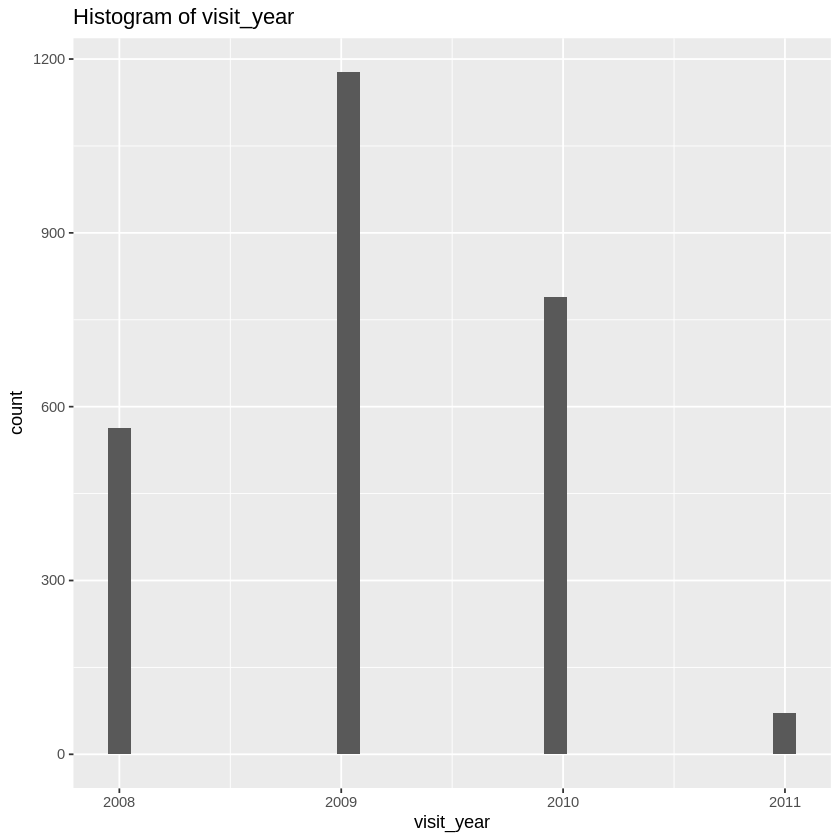

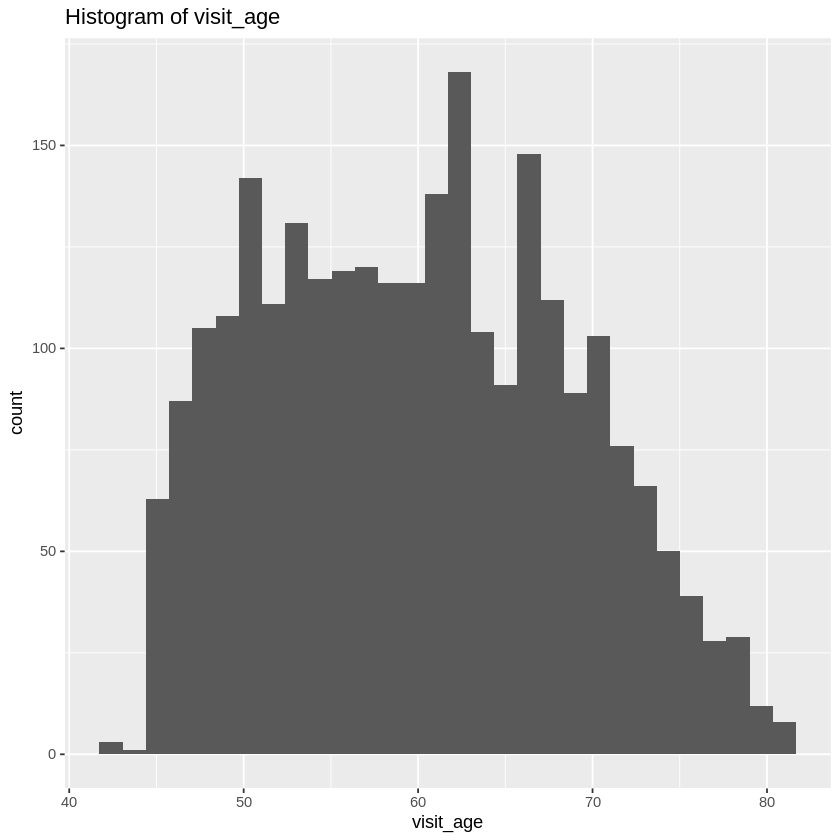

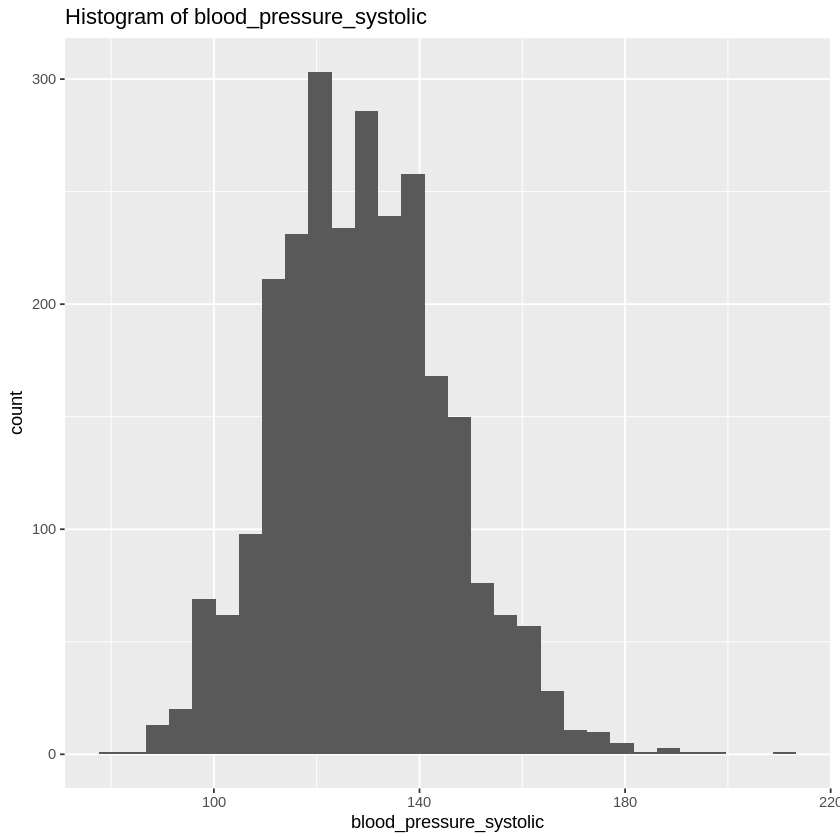

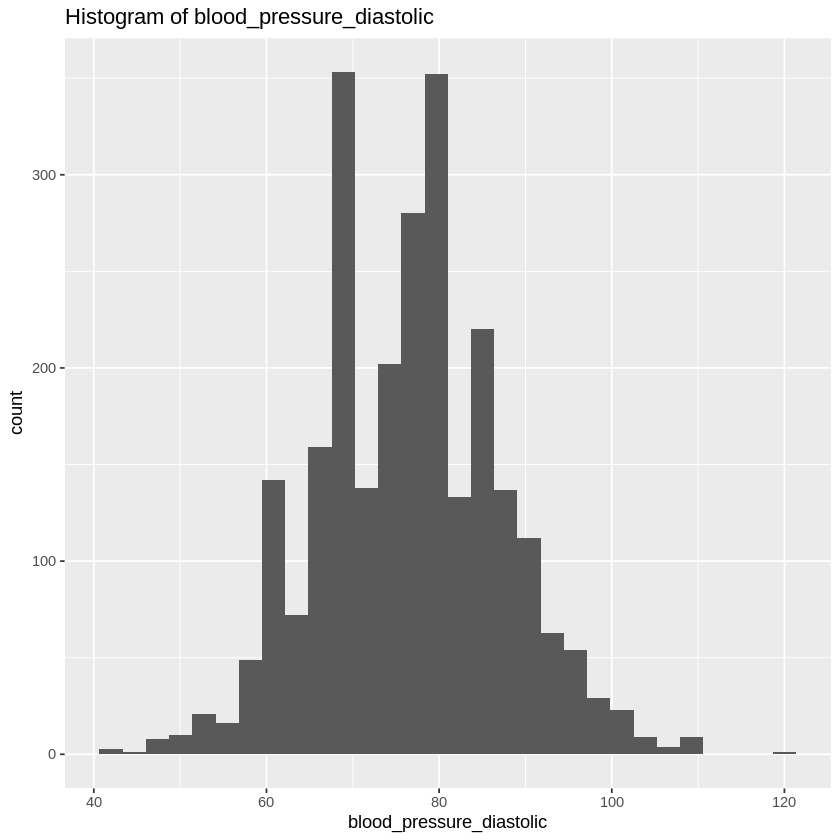

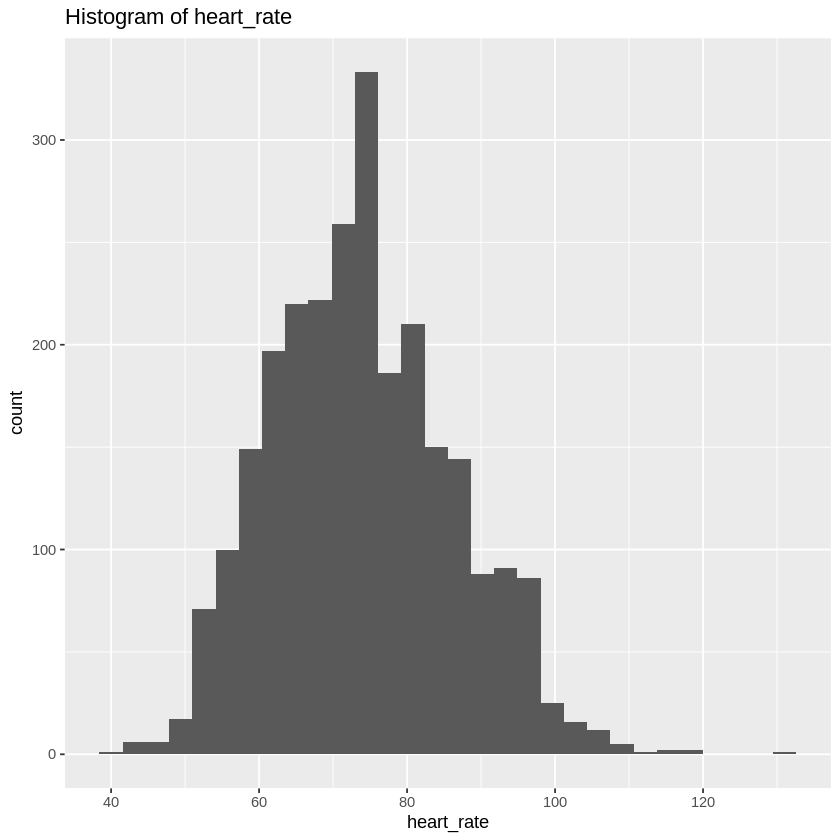

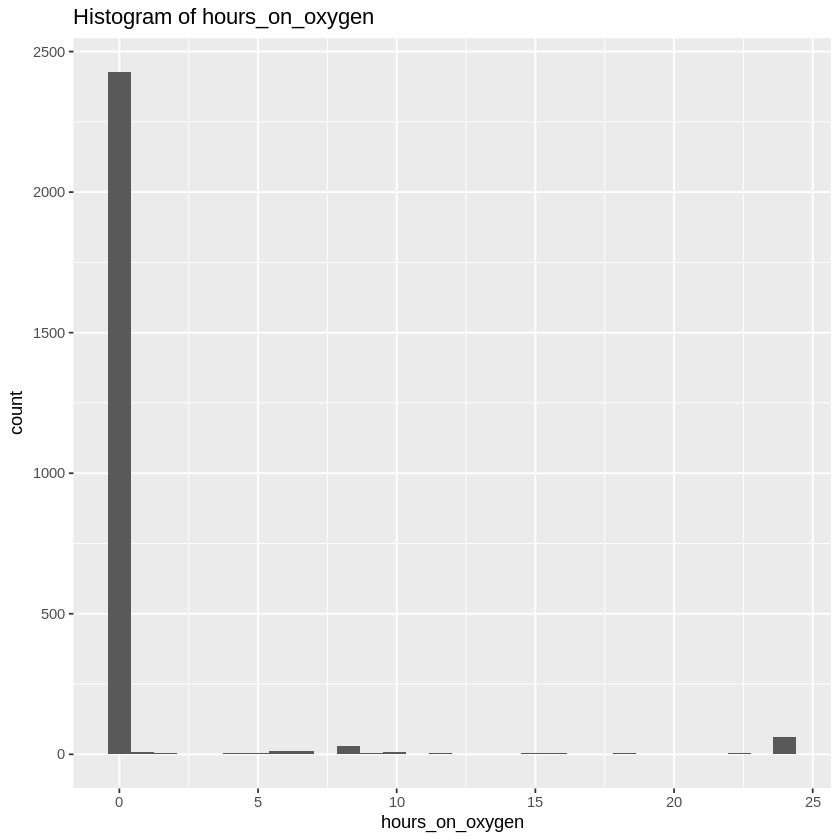

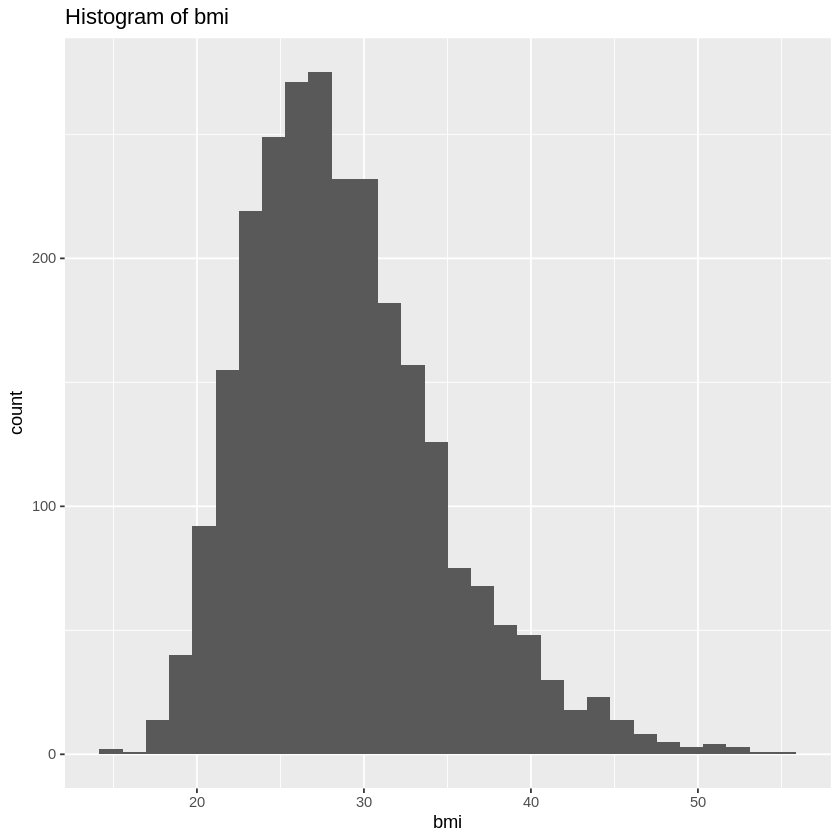

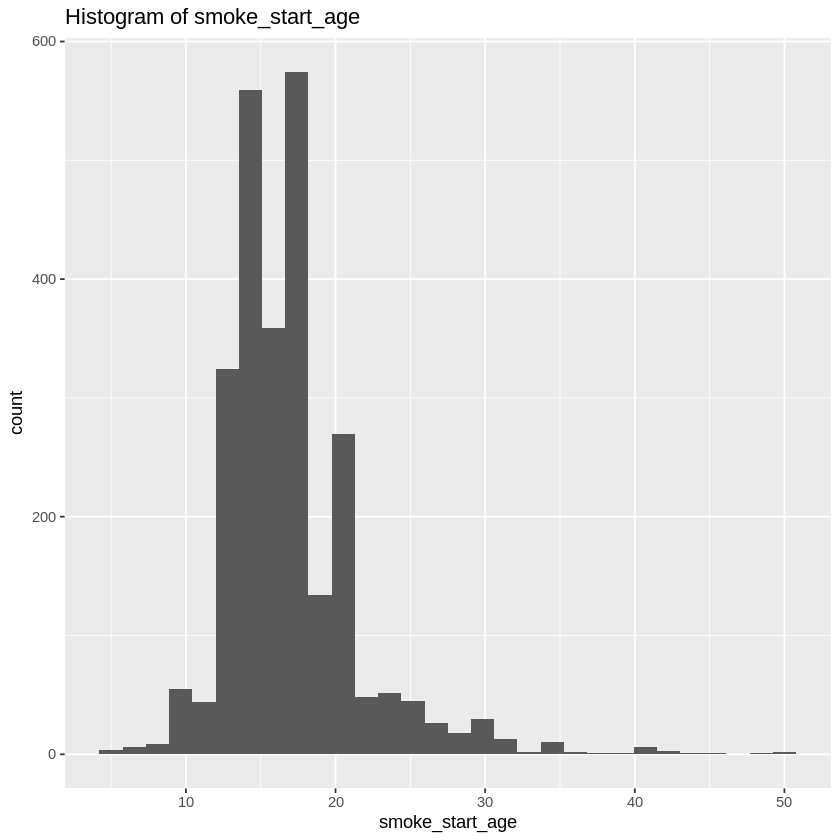

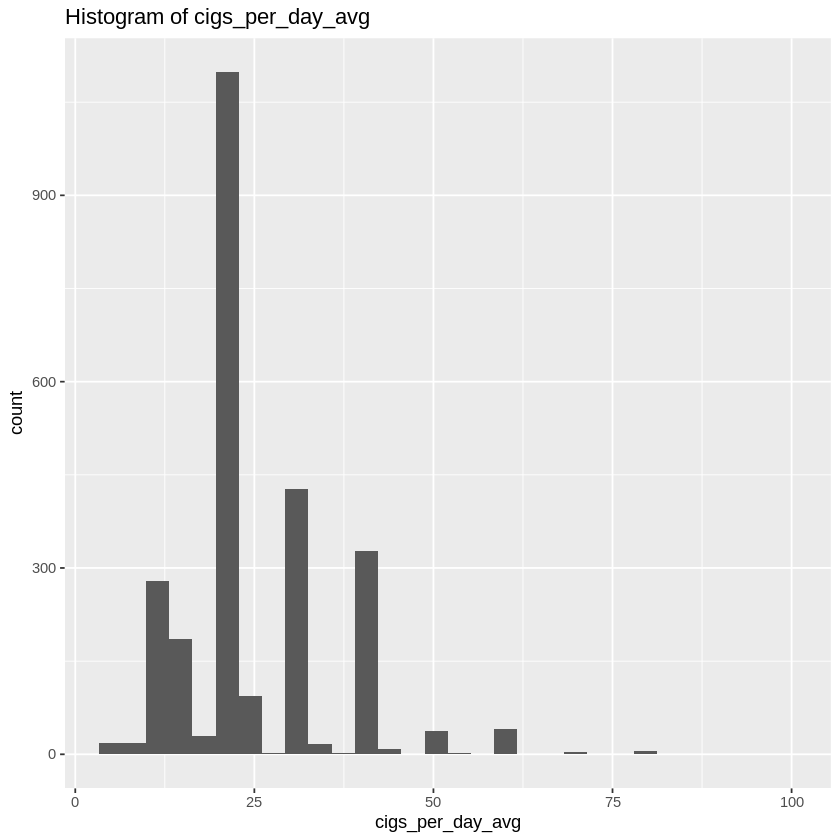

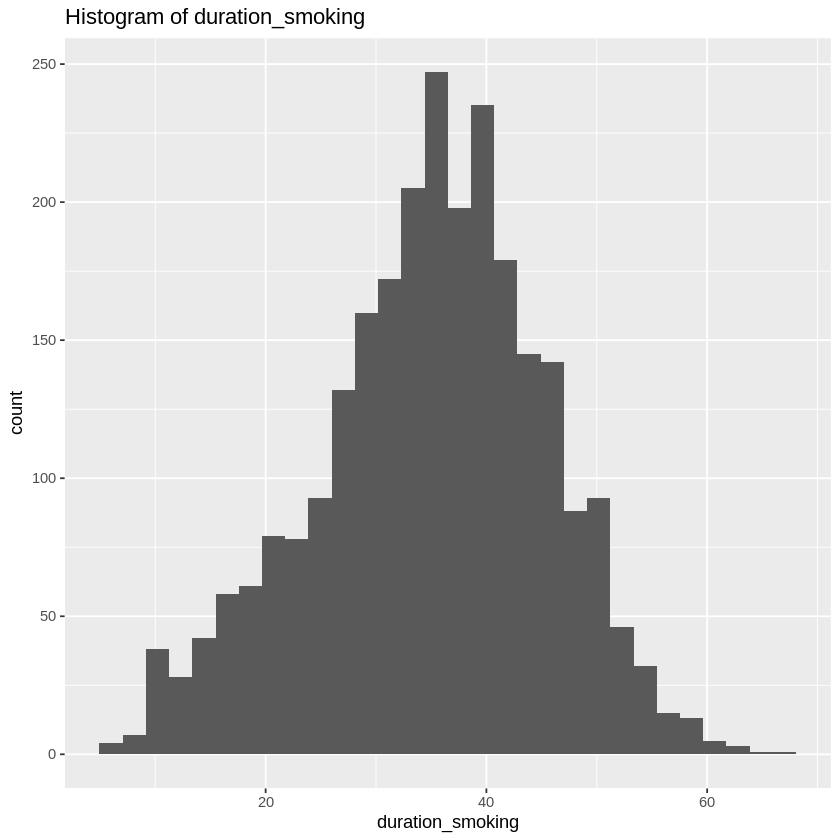

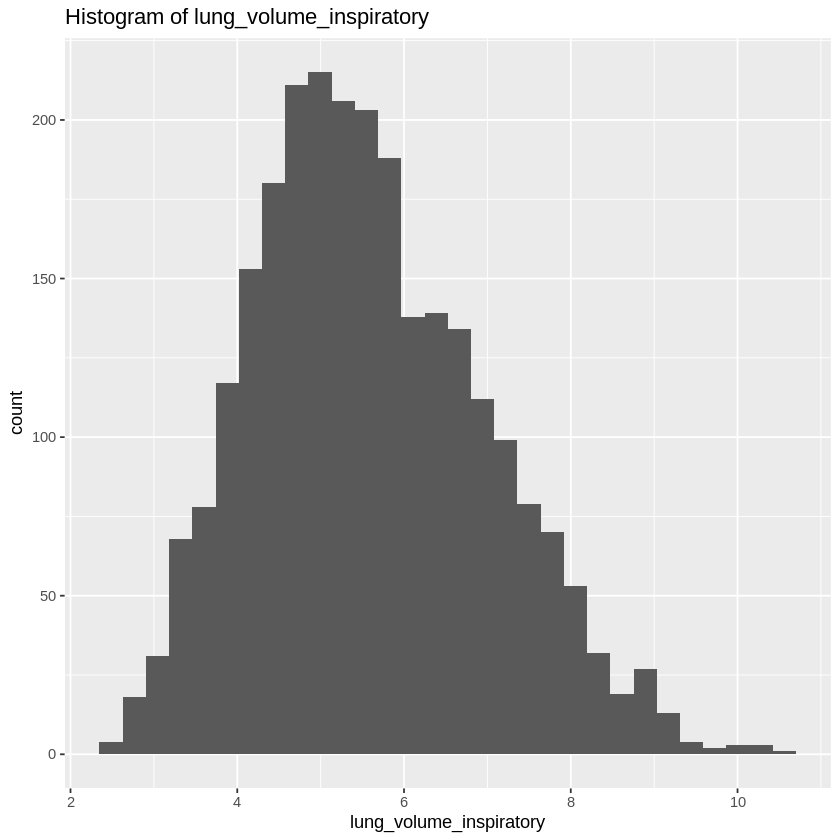

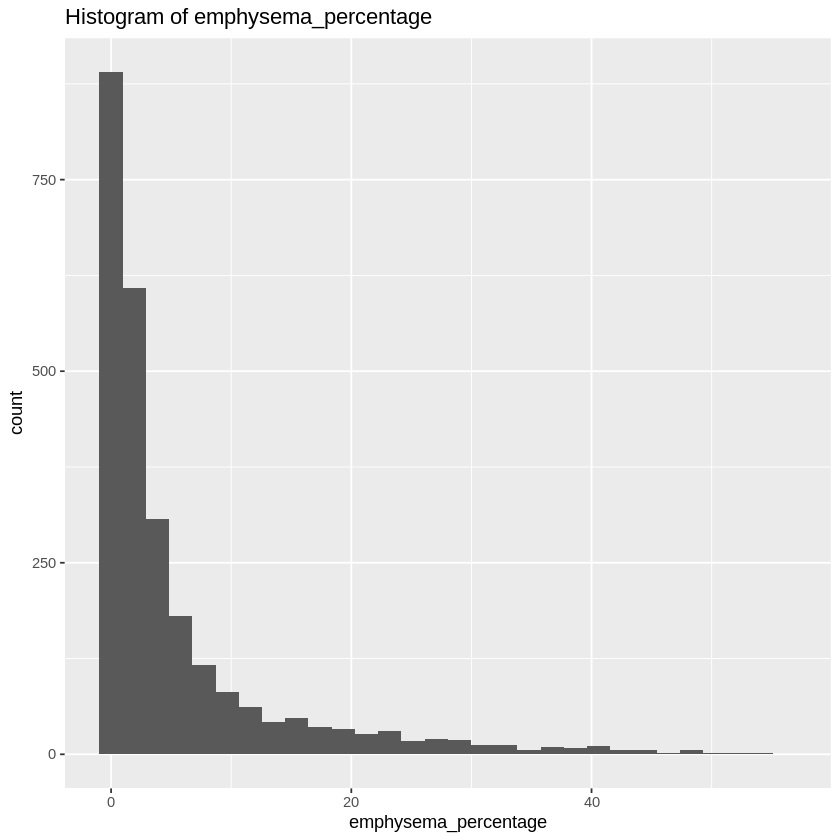

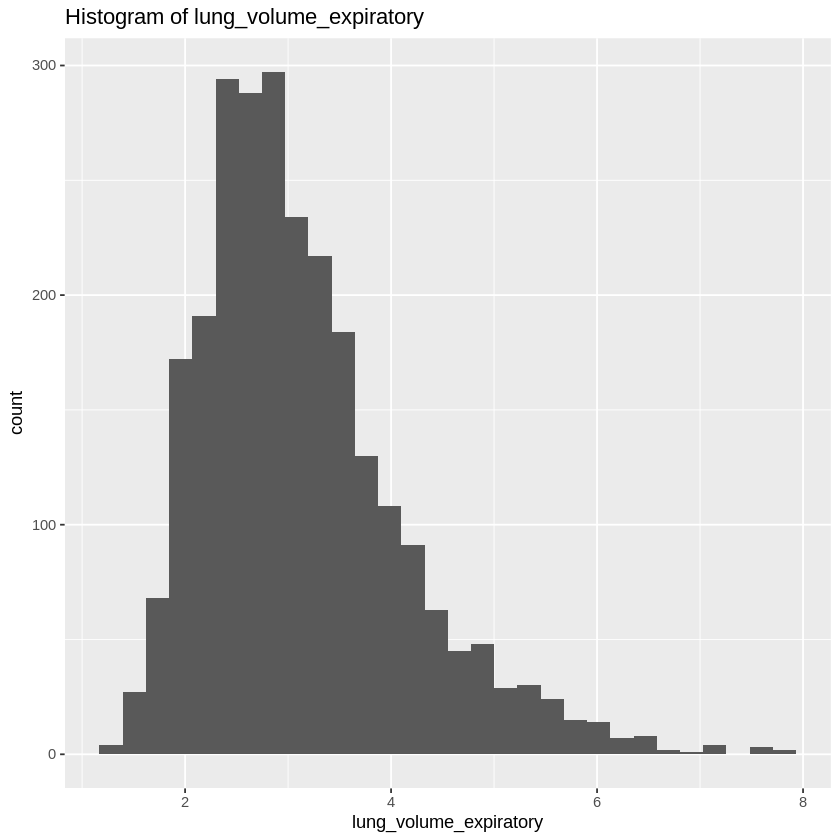

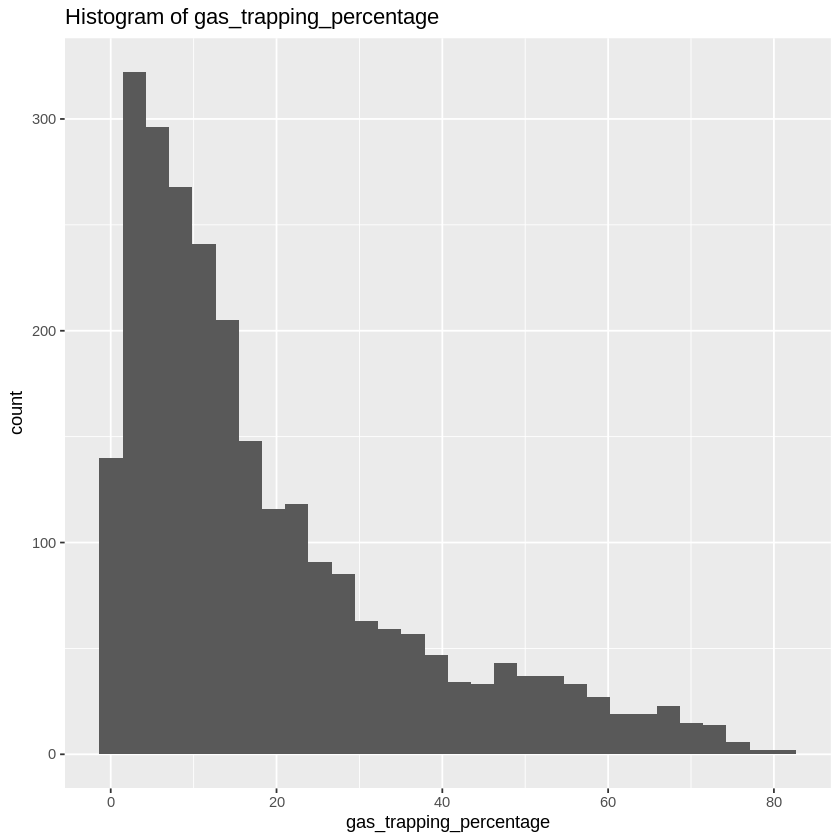

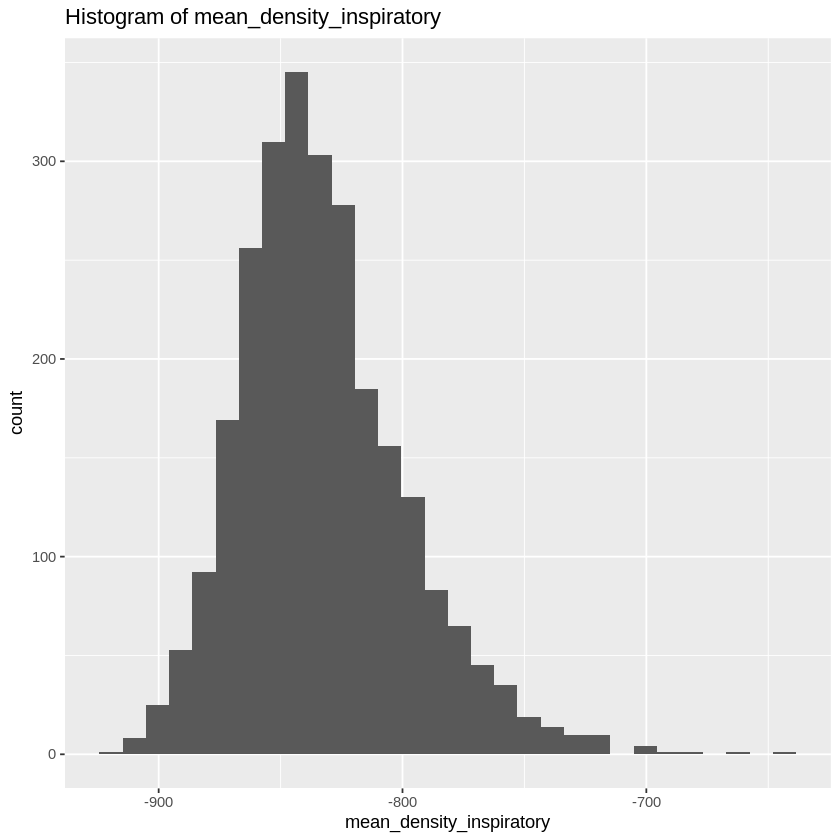

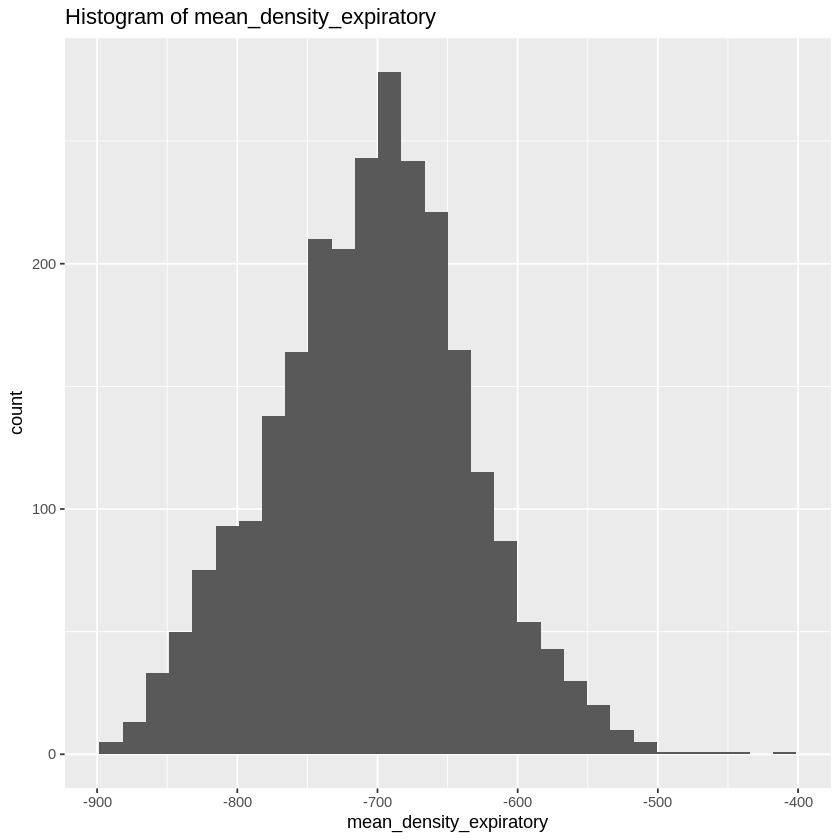

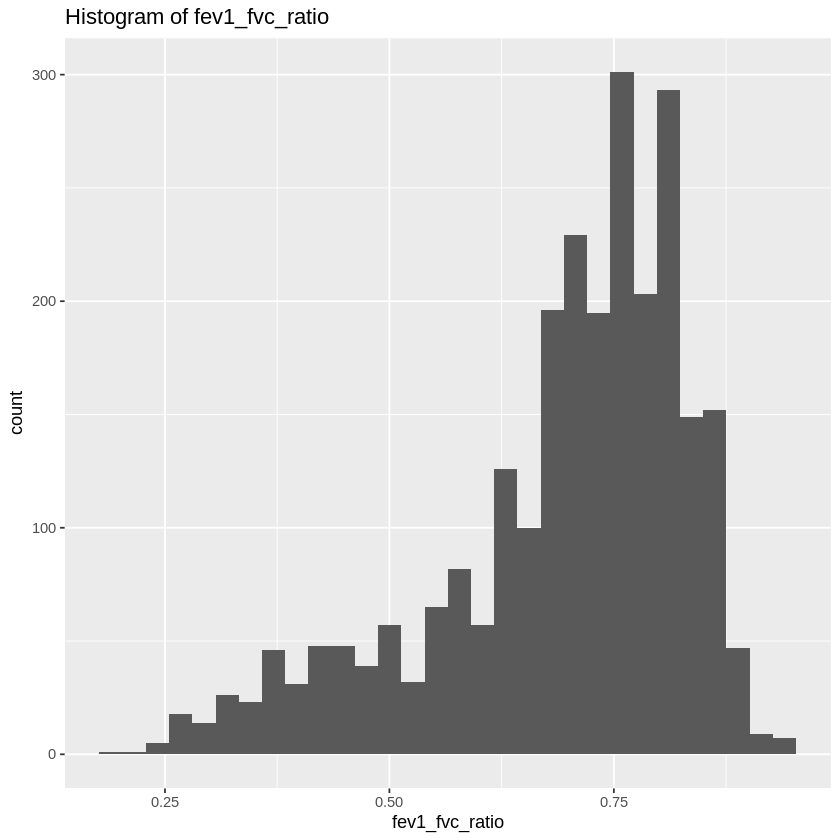

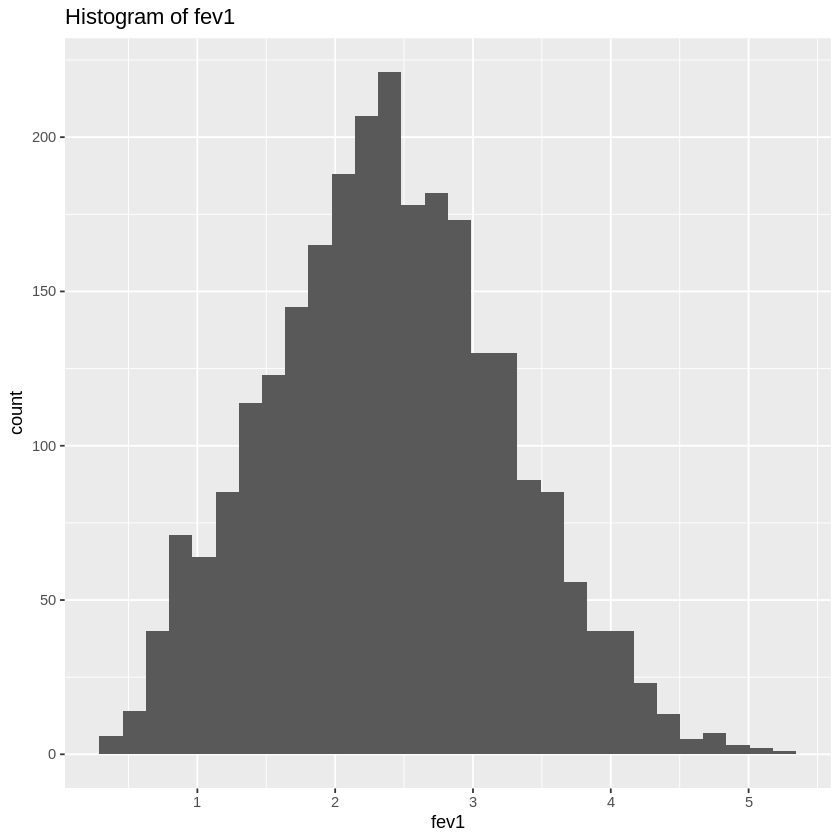

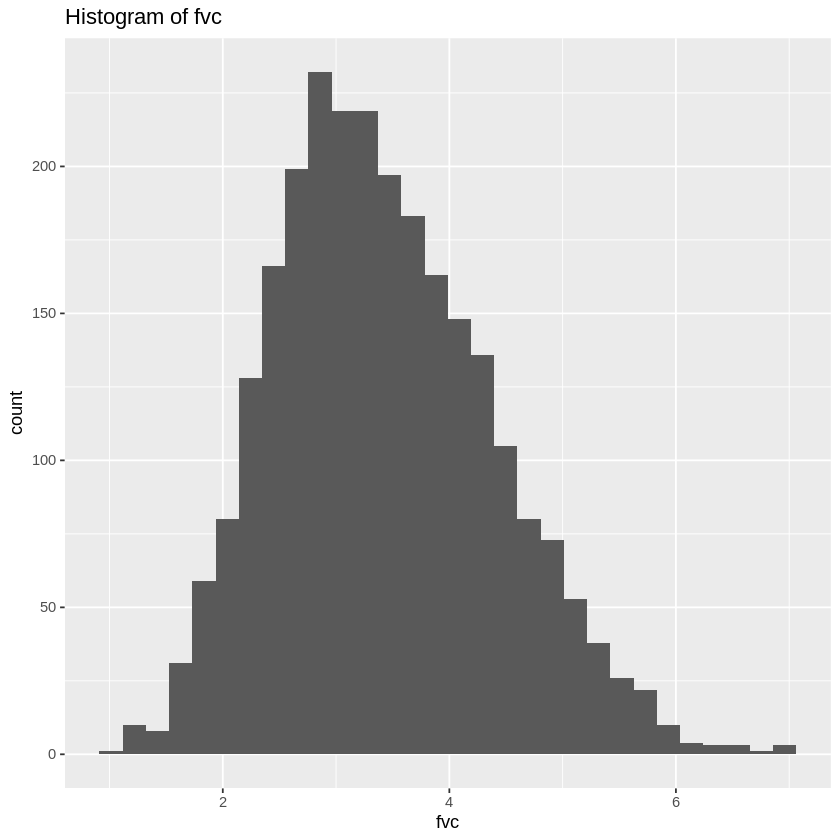

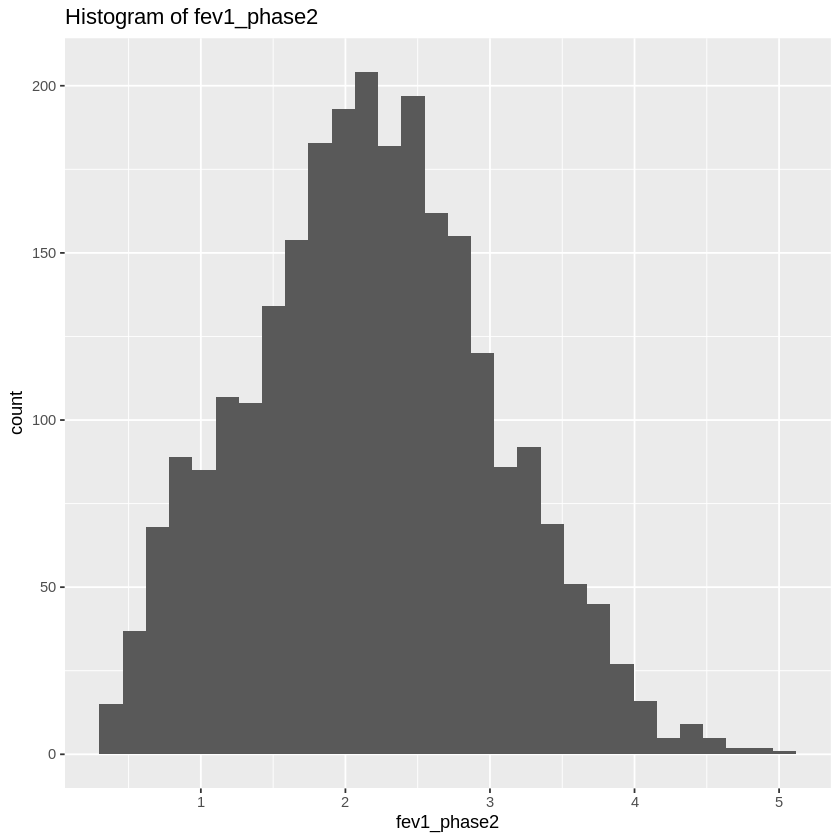

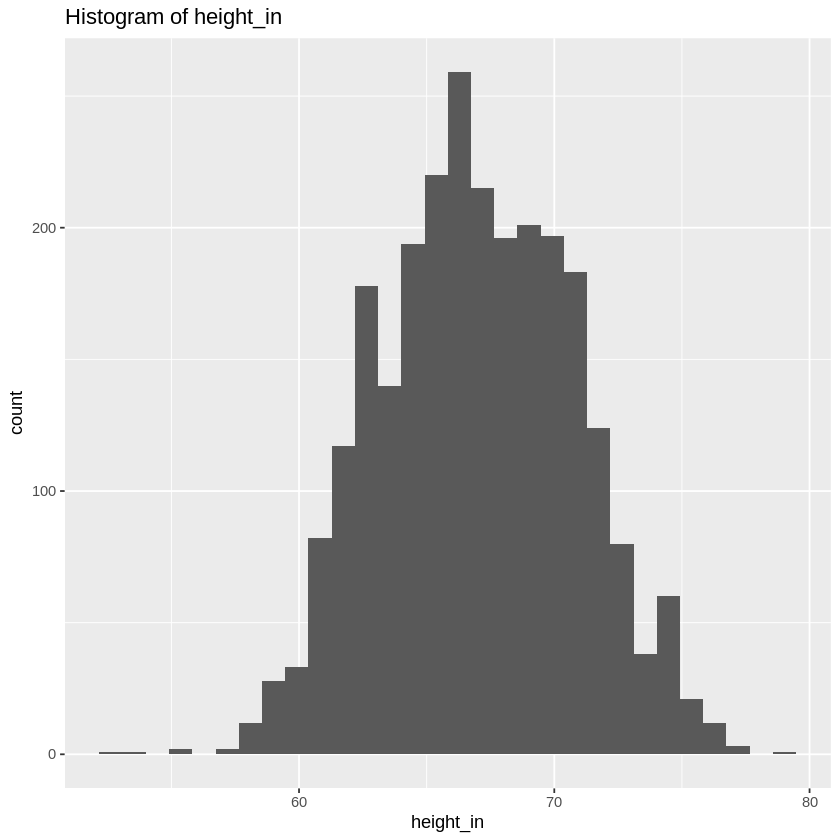

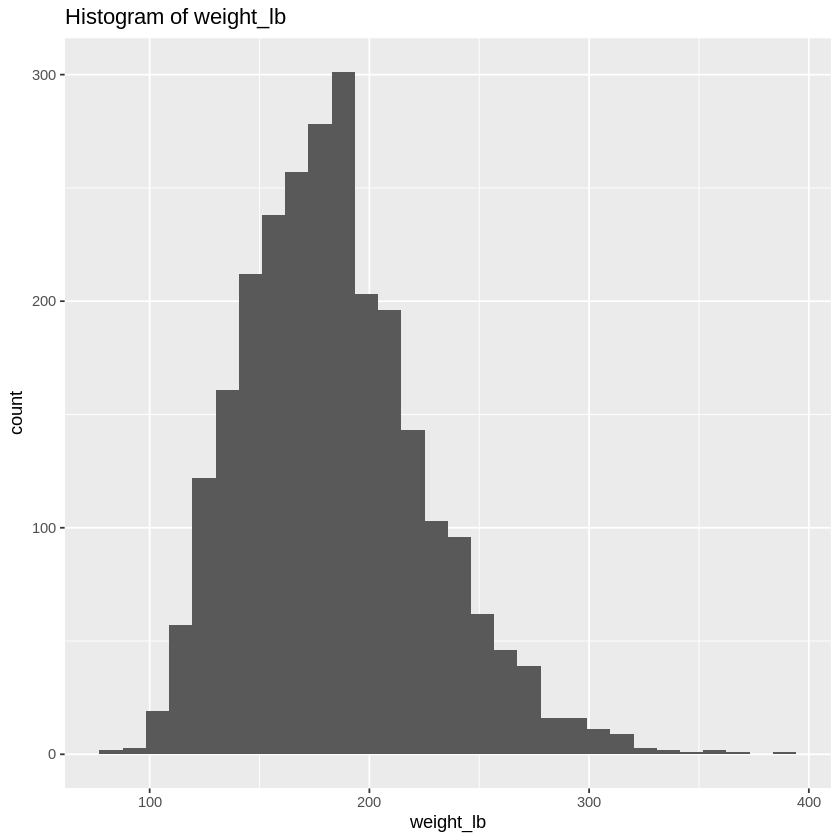

In [30]:
# install ggplot2 package if needed

install.packages("ggplot2")

# load ggplot2 package

library(ggplot2)

# identify numeric variables in dataset

numeric_variables <- names(copd_data)[sapply(copd_data, is.numeric)]

# create histogram for each numeric variable

for(i in numeric_variables) {

  print(

    ggplot(data = copd_data,
           aes_string(x = i)) +

      geom_histogram(bins = 30) +

      ggtitle(paste("Histogram of", i))

  )
}

In [31]:
# view all variable names
names(copd_data)

[1] "sid"                      "visit_year"              
 [3] "visit_date"               "visit_age"               
 [5] "gender"                   "race"                    
 [7] "smoking_status"           "blood_pressure_systolic" 
 [9] "blood_pressure_diastolic" "heart_rate"              
[11] "hours_on_oxygen"          "bmi"                     
[13] "smoke_start_age"          "cigs_per_day_avg"        
[15] "duration_smoking"         "lung_volume_inspiratory" 
[17] "emphysema_percentage"     "lung_volume_expiratory"  
[19] "gas_trapping_percentage"  "mean_density_inspiratory"
[21] "mean_density_expiratory"  "fev1_fvc_ratio"          
[23] "fev1"                     "fvc"                     
[25] "fev1_phase2"              "height_in"               
[27] "weight_lb"                "hay_fever"               
[29] "asthma"                   "bronchitis_attacks"      
[31] "chronic_bronchitis"       "pneumonia"               
[33] "emphysema"                "copd"                    
[35] "sleep_apnea"

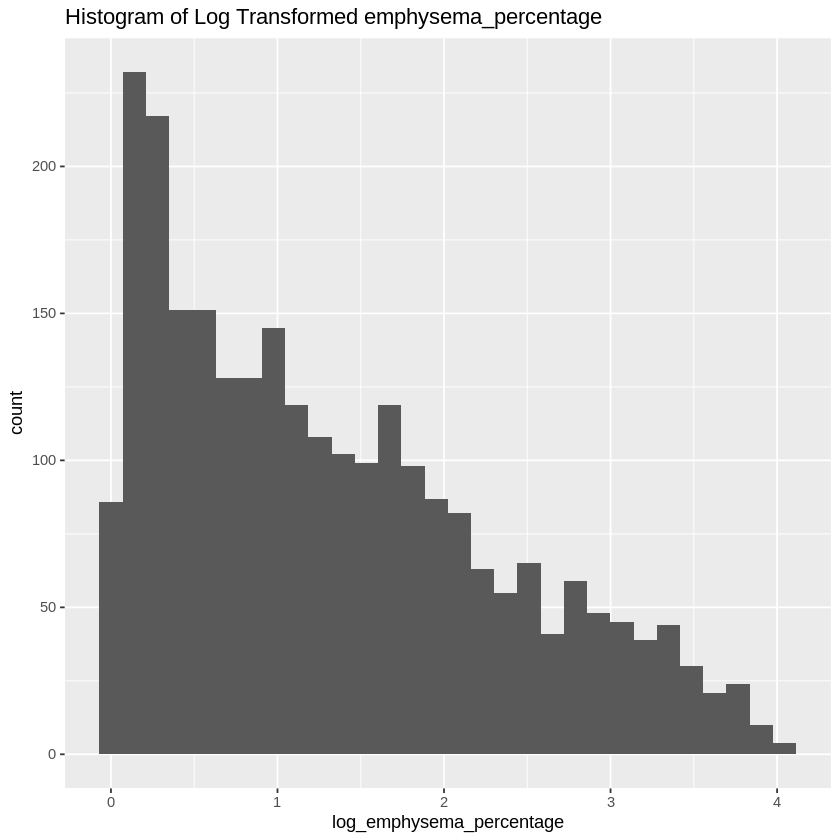

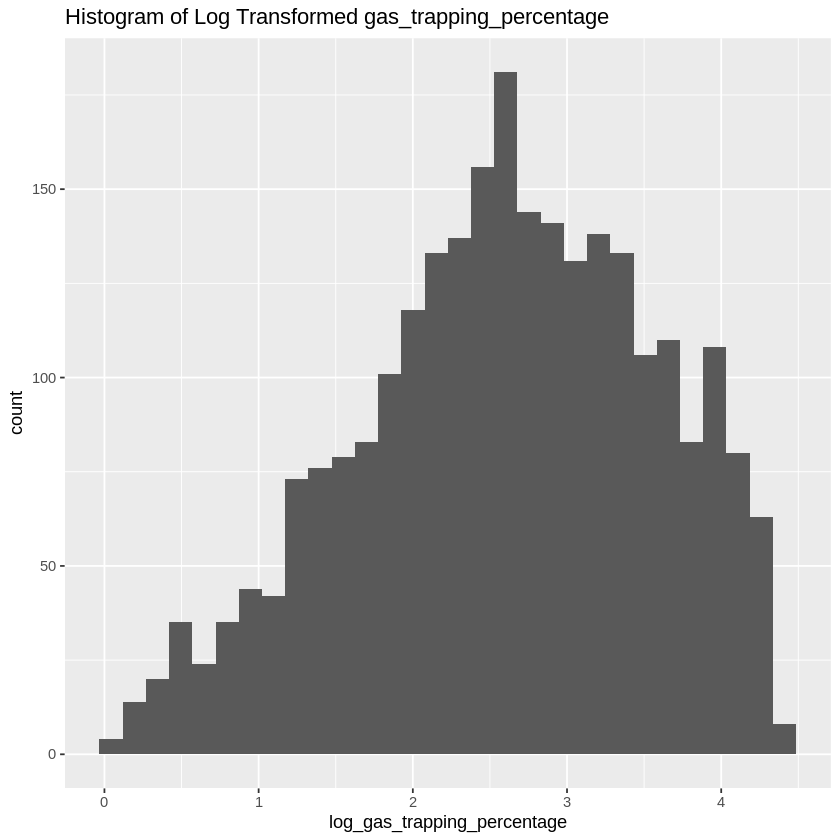

In [32]:
# log transform emphysema_percentage

copd_data$log_emphysema_percentage <- log(copd_data$emphysema_percentage + 1)

# histogram of transformed emphysema_percentage

ggplot(data = copd_data,
       aes(x = log_emphysema_percentage)) +

  geom_histogram(bins = 30) +

  ggtitle("Histogram of Log Transformed emphysema_percentage")

# log transform gas_trapping_percentage

copd_data$log_gas_trapping_percentage <- log(copd_data$gas_trapping_percentage + 1)

# histogram of transformed gas_trapping_percentage

ggplot(data = copd_data,
       aes(x = log_gas_trapping_percentage)) +

  geom_histogram(bins = 30) +

  ggtitle("Histogram of Log Transformed gas_trapping_percentage")

<br>

---

<br>






####<font color=red>Task 11</font>

We are primarily interested in the breathing function of the clinical trial participants after five years (`fev1_phase2`).

Using `ggplot` covered in the course,

1. Visualize the relationship between `fev1_phase2` and at least five categorical variables in your data frame

2. What are your observations? Based on your data visualizations, do there appear to be any differences in `fev1_phase2` between groups?

In [33]:
names(copd_data)

[1] "sid"                         "visit_year"                 
 [3] "visit_date"                  "visit_age"                  
 [5] "gender"                      "race"                       
 [7] "smoking_status"              "blood_pressure_systolic"    
 [9] "blood_pressure_diastolic"    "heart_rate"                 
[11] "hours_on_oxygen"             "bmi"                        
[13] "smoke_start_age"             "cigs_per_day_avg"           
[15] "duration_smoking"            "lung_volume_inspiratory"    
[17] "emphysema_percentage"        "lung_volume_expiratory"     
[19] "gas_trapping_percentage"     "mean_density_inspiratory"   
[21] "mean_density_expiratory"     "fev1_fvc_ratio"             
[23] "fev1"                        "fvc"                        
[25] "fev1_phase2"                 "height_in"                  
[27] "weight_lb"                   "hay_fever"                  
[29] "asthma"                      "bronchitis_attacks"         
[31] "chronic_bronchitis"          "pneumonia"                  
[33] "emphysema"                   "copd"                       
[35] "sleep_apnea"                 "log_emphysema_percentage"   
[37] "log_gas_trapping_percentage"

In [34]:
str(copd_data)

'data.frame':	2600 obs. of  37 variables:
 $ sid                        : chr  "10005Q" "10055F" "10056H" "10060Y" ...
 $ visit_year                 : int  2008 2008 2008 2008 2008 2008 2008 2008 2008 2008 ...
 $ visit_date                 : chr  "1/15/2008" "3/15/2008" "2/15/2008" "5/15/2008" ...
 $ visit_age                  : num  54.5 69 48.7 72.8 76.2 70 61.8 69.6 47.8 71.5 ...
 $ gender                     : Factor w/ 2 levels "Male","Female": 2 1 2 1 2 2 1 2 1 1 ...
 $ race                       : Factor w/ 2 levels "Non-Hispanic White",..: 1 2 1 1 1 1 1 1 1 1 ...
 $ smoking_status             : Factor w/ 2 levels "Former Smoker",..: 2 1 1 1 1 1 1 1 2 1 ...
 $ blood_pressure_systolic    : int  130 168 100 147 134 92 108 144 139 140 ...
 $ blood_pressure_diastolic   : int  80 100 53 71 78 58 78 90 90 75 ...
 $ heart_rate                 : int  87 55 98 87 92 77 72 110 87 73 ...
 $ hours_on_oxygen            : int  0 0 24 24 0 12 0 0 0 24 ...
 $ bmi                        : num  2

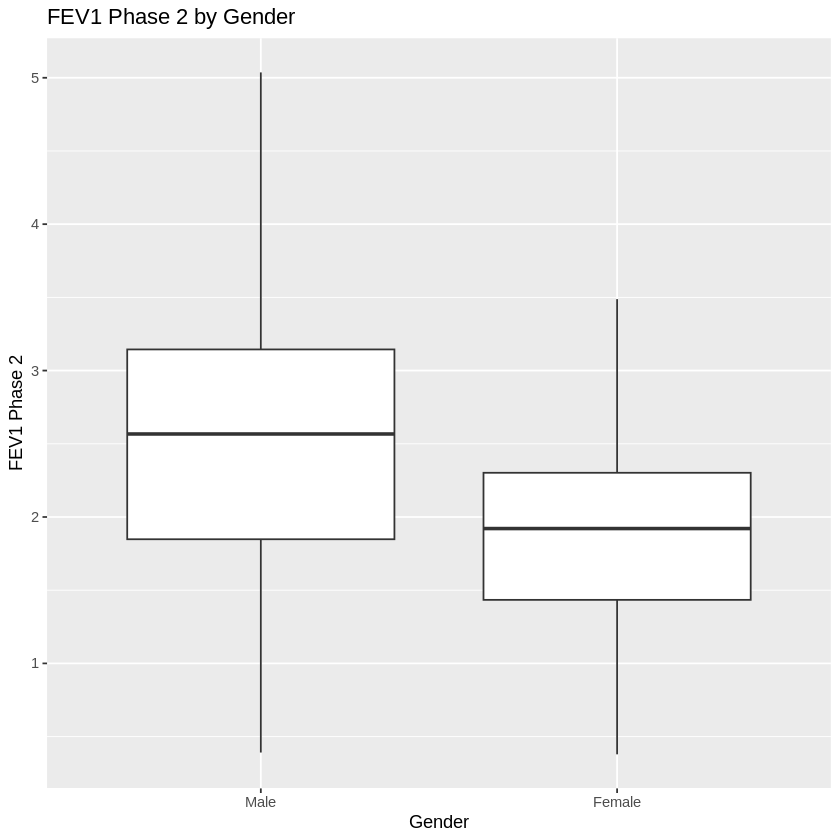

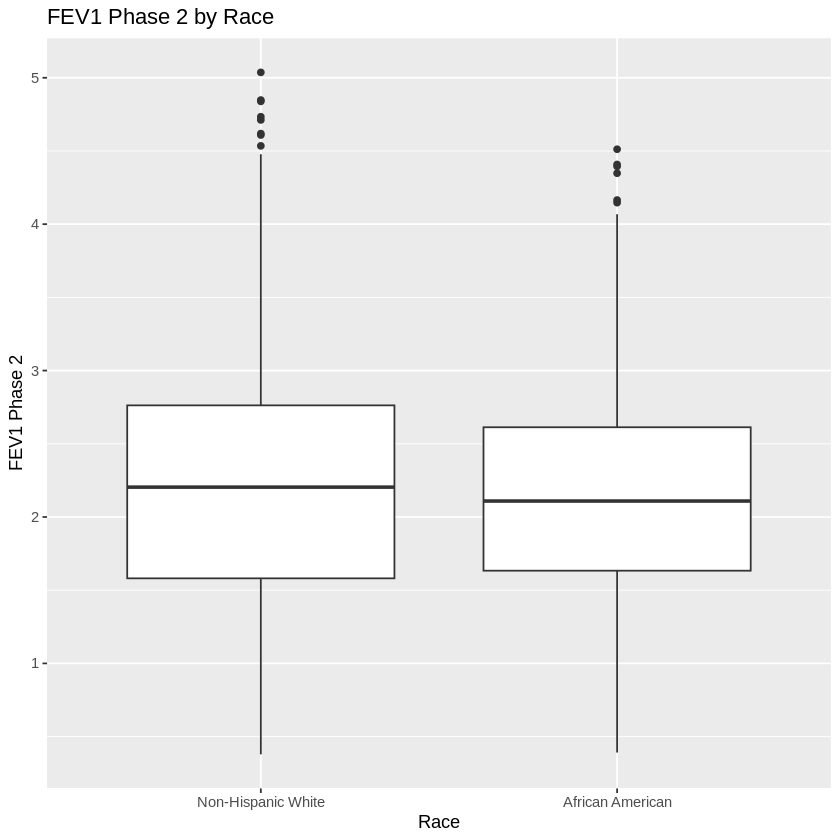

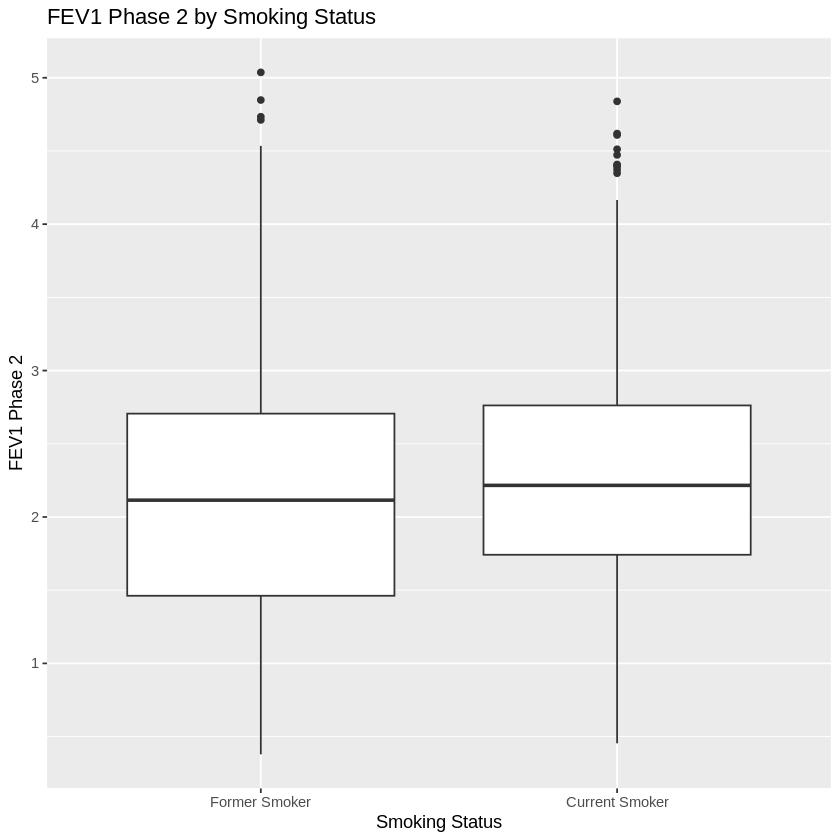

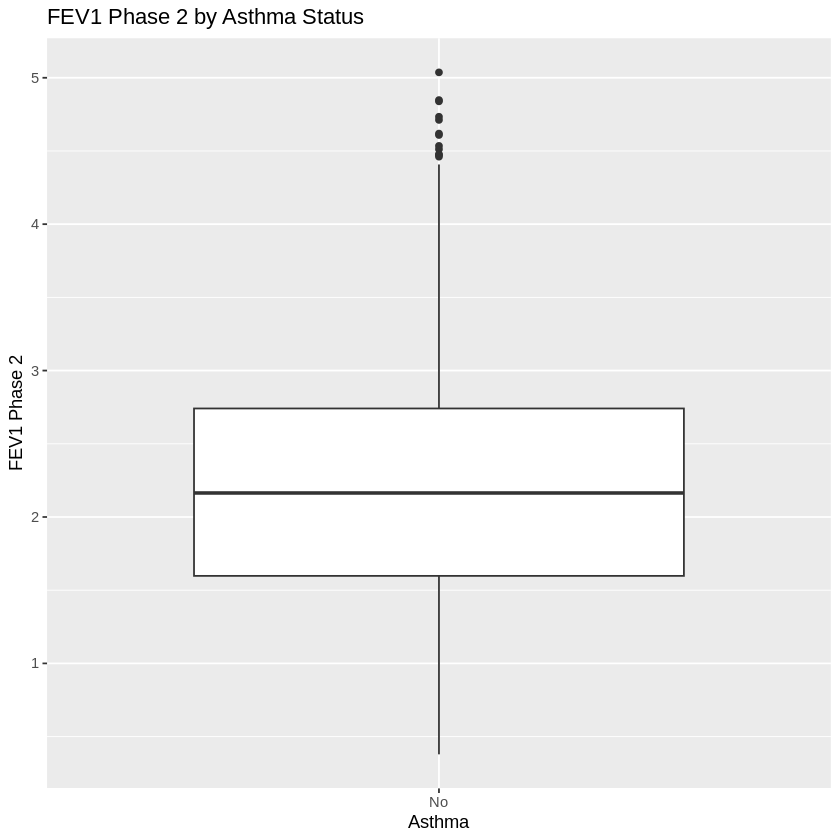

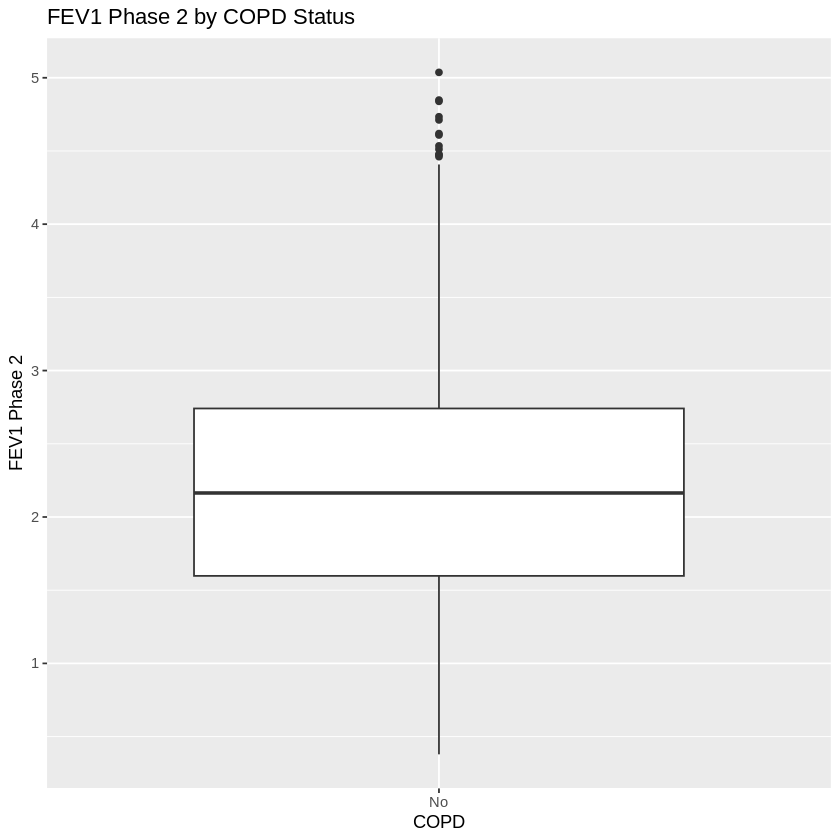

In [35]:
# Gender
ggplot(copd_data, aes(x = gender, y = fev1_phase2)) +
  geom_boxplot() +
  ggtitle("FEV1 Phase 2 by Gender") +
          xlab("Gender") +
          ylab("FEV1 Phase 2")

# Race
ggplot(copd_data, aes(x = race, y = fev1_phase2)) +
  geom_boxplot() +
  ggtitle("FEV1 Phase 2 by Race") +
          xlab("Race") +
          ylab("FEV1 Phase 2")

# Smoking Status
ggplot(copd_data, aes(x = smoking_status, y = fev1_phase2)) +
  geom_boxplot() +
  ggtitle("FEV1 Phase 2 by Smoking Status") +
          xlab("Smoking Status") +
          ylab("FEV1 Phase 2")

# Asthma
ggplot(copd_data, aes(x = asthma, y = fev1_phase2)) +
  geom_boxplot() +
  ggtitle("FEV1 Phase 2 by Asthma Status") +
          xlab("Asthma") +
          ylab("FEV1 Phase 2")

# COPD
ggplot(copd_data, aes(x = copd, y = fev1_phase2)) +
  geom_boxplot() +
  ggtitle("FEV1 Phase 2 by COPD Status") +
          xlab("COPD") +
          ylab("FEV1 Phase 2")

The relationship between `fev1_phase2` and five categorical variables (gender, race, smoking status, asthma, and COPD status) was examined using boxplots. Overall, smoking status shows the most noticeable differences in `fev1_phase2`, with former smokers generally displaying higher lung function compared to current smokers. Gender and race show smaller differences with overlapping distributions between groups.

For asthma and COPD status, there is small variation in `fev1_phase2` within categories, suggesting weaker or less distinct associations in this dataset. Overall, smoking behavior appears to have the strongest relationship with long term lung function compared to the other categorical variables that were analyzed.

<br>

<br>

<br>

---

<br>






####<font color=red>Task 12</font>

We are primarily interested in the breathing function of the clinical trial participants after five years (`fev1_phase2`).

Using `ggplot` covered in the course,

1. Visualize the relationship between `fev1_phase2` and at least ***five*** numeric variables in your data frame

2. What are your observations? Based on your data visualizations, does there appear to be any relationships between these variables and `fev1_phase2`? Are these relationships linear? something else?

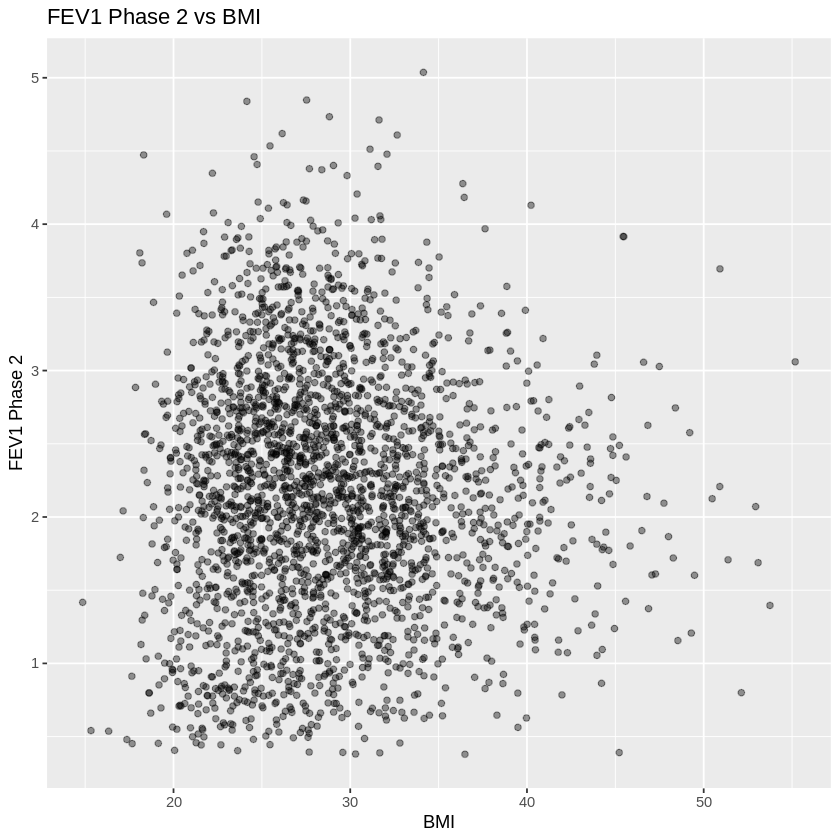

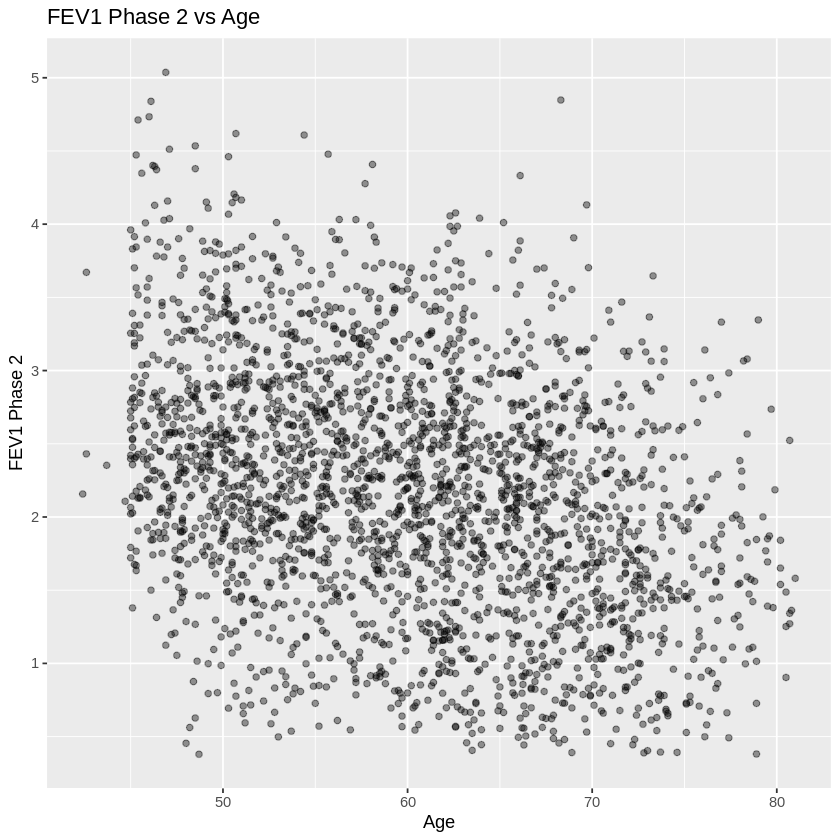

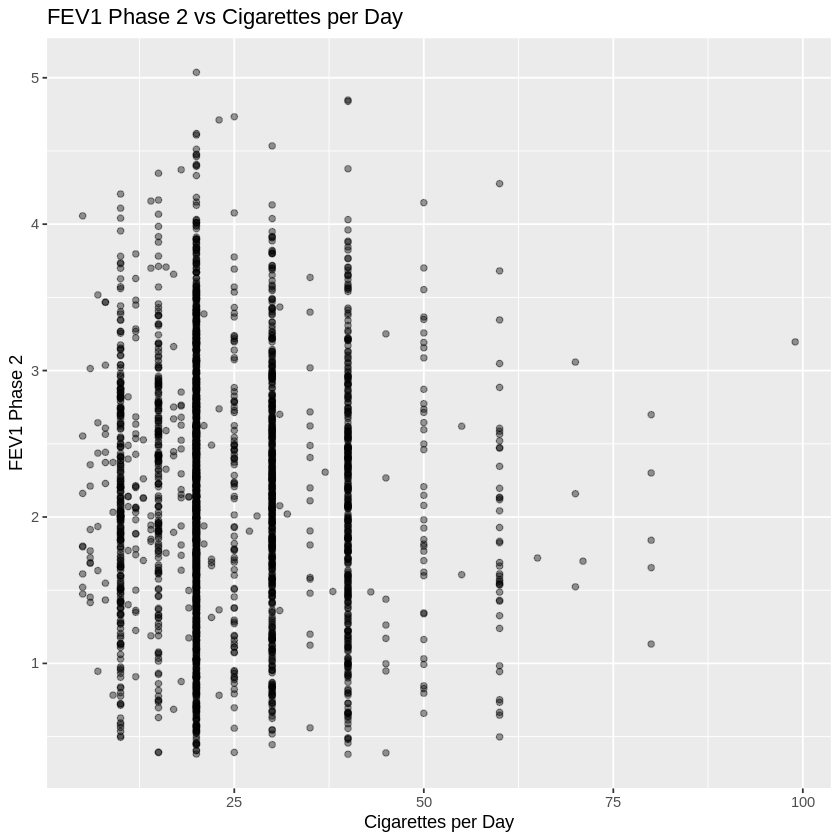

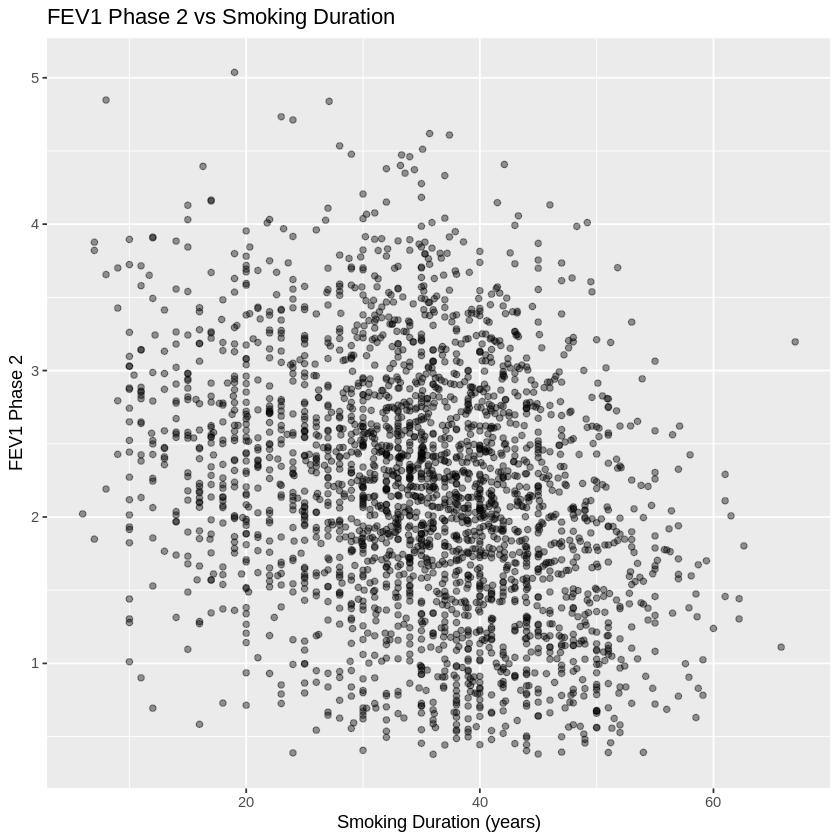

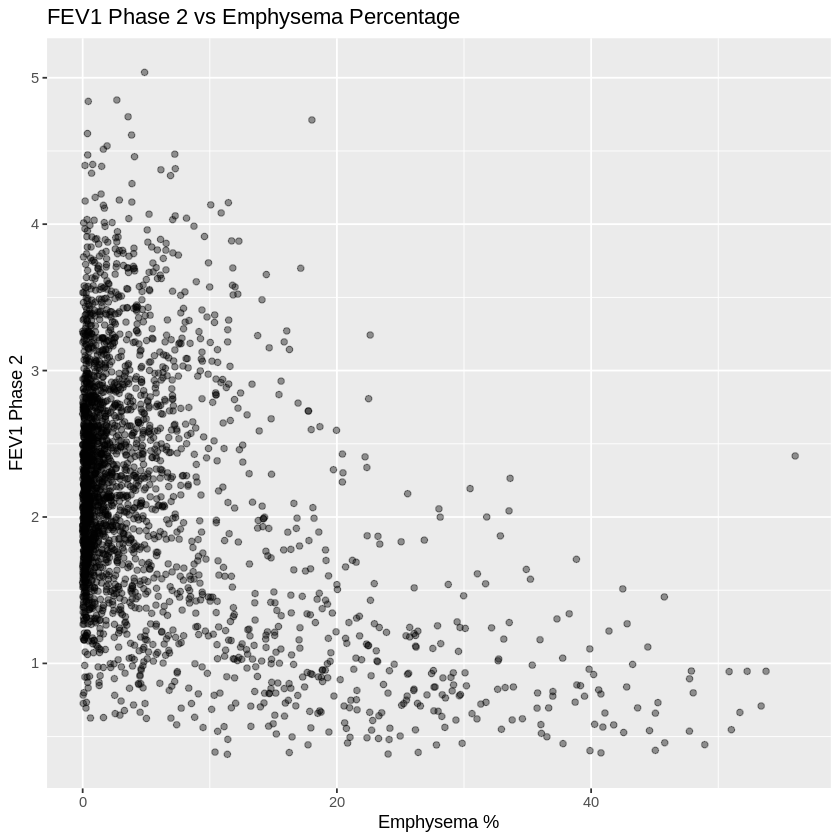

In [36]:
# 1. BMI
ggplot(copd_data, aes(x = bmi, y = fev1_phase2)) +
  geom_point(alpha = 0.4) +
  ggtitle("FEV1 Phase 2 vs BMI") +
          xlab("BMI") +
          ylab("FEV1 Phase 2")

# 2. Age
ggplot(copd_data, aes(x = visit_age, y = fev1_phase2)) +
  geom_point(alpha = 0.4) +
  ggtitle("FEV1 Phase 2 vs Age") +
          xlab("Age") +
          ylab("FEV1 Phase 2")

# 3. Smoking intensity (cigs per day)
ggplot(copd_data, aes(x = cigs_per_day_avg, y = fev1_phase2)) +
  geom_point(alpha = 0.4) +
  ggtitle("FEV1 Phase 2 vs Cigarettes per Day") +
          xlab("Cigarettes per Day") +
          ylab("FEV1 Phase 2")

# 4. Duration of smoking
ggplot(copd_data, aes(x = duration_smoking, y = fev1_phase2)) +
  geom_point(alpha = 0.4) +
  ggtitle("FEV1 Phase 2 vs Smoking Duration") +
          xlab("Smoking Duration (years)") +
          ylab("FEV1 Phase 2")

# 5. Emphysema percentage
ggplot(copd_data, aes(x = emphysema_percentage, y = fev1_phase2)) +
  geom_point(alpha = 0.4) +
  ggtitle("FEV1 Phase 2 vs Emphysema Percentage") +
          xlab("Emphysema %") +
          ylab("FEV1 Phase 2")

The relationship between `fev1_phase2` and five numeric variables (BMI, age, cigarettes per day, smoking duration, and emphysema percentage) was examined using scatterplots. Overall, several variables show weak to moderate negative relationships with `fev1_phase2`. In particular, emphysema percentage and smoking related variables (cigarettes per day and smoking duration) tend to be associated with lower `fev1_phase2` values, suggesting reduced lung function with increased smoking exposure and lung damage.

BMI and age showed weaker and less consistent patterns, with more scatter and no clear linear relationship. Most relationships are not perfectly linear. Instead, they appear to show noisy or slightly curved trends, indicating that `fev1_phase2` is likely influenced by more than one interacting factors rather than a single linear predictor.

<br>

<br>

---






## Inference and Modeling

####<font color=red>Task 13</font>

Using code covered in the course,

1. Conduct a statistical test to determine if there is a significant difference in `fev1_phase2` between groups from your ***five*** categorical variables in Task 11.

In [44]:
# Oxygen use
copd_data$oxygen_group <- ifelse(copd_data$hours_on_oxygen > 0,
                                 "On Oxygen", "Not On Oxygen")

# BMI
copd_data$bmi_binary <- ifelse(copd_data$bmi >= 25,
                               "Overweight_or_Obese", "Not_Overweight")

In [45]:
# Gender
t.test(fev1_phase2 ~ gender, data = copd_data)

# Race
t.test(fev1_phase2 ~ race, data = copd_data)

# Smoking status
t.test(fev1_phase2 ~ smoking_status, data = copd_data)

# Oxygen use
t.test(fev1_phase2 ~ oxygen_group, data = copd_data)

# BMI group
t.test(fev1_phase2 ~ bmi_binary, data = copd_data)


	Welch Two Sample t-test

data:  fev1_phase2 by gender
t = 20.506, df = 2375.2, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Male and group Female is not equal to 0
95 percent confidence interval:
 0.5621591 0.6810454
sample estimates:
  mean in group Male mean in group Female 
            2.483803             1.862200 



	Welch Two Sample t-test

data:  fev1_phase2 by race
t = 1.616, df = 1450.7, p-value = 0.1063
alternative hypothesis: true difference in means between group Non-Hispanic White and group African American is not equal to 0
95 percent confidence interval:
 -0.01207289  0.12497344
sample estimates:
mean in group Non-Hispanic White   mean in group African American 
                        2.194220                         2.137769 



	Welch Two Sample t-test

data:  fev1_phase2 by smoking_status
t = -4.6767, df = 2592.3, p-value = 3.064e-06
alternative hypothesis: true difference in means between group Former Smoker and group Current Smoker is not equal to 0
95 percent confidence interval:
 -0.21584171 -0.08831391
sample estimates:
 mean in group Former Smoker mean in group Current Smoker 
                    2.108486                     2.260564 



	Welch Two Sample t-test

data:  fev1_phase2 by oxygen_group
t = 19.767, df = 211.68, p-value < 2.2e-16
alternative hypothesis: true difference in means between group Not On Oxygen and group On Oxygen is not equal to 0
95 percent confidence interval:
 0.9366593 1.1441718
sample estimates:
mean in group Not On Oxygen     mean in group On Oxygen 
                   2.248128                    1.207713 



	Welch Two Sample t-test

data:  fev1_phase2 by bmi_binary
t = -3.0303, df = 1218.6, p-value = 0.002495
alternative hypothesis: true difference in means between group Not_Overweight and group Overweight_or_Obese is not equal to 0
95 percent confidence interval:
 -0.18883147 -0.04041104
sample estimates:
     mean in group Not_Overweight mean in group Overweight_or_Obese 
                         2.095488                          2.210109 


Independent two-sample t-tests were conducted to assess whether `fev1_phase2` differed significantly between groups across five categorical variables: gender, race, smoking status, oxygen use group, and BMI category.

The results suggest that smoking status and oxygen use group show the strongest differences in mean `fev1_phase2`, indicating that behavioral factors and disease severity are associated with reduced lung function after five years. Gender and race showed smaller differences in mean `fev1_phase2`, with a lot of overlap between group distributions. BMI category also shows variation in `fev1_phase2`, suggesting a possible relationship between body composition and lung function. Overall, smoking behavior and clinical severity indicators appear to have stronger associations with `fev1_phase2` than the demographic variables alone.

---





####<font color=red>Task 14</font>

Using code covered in the course,

1. Fit 5 simple linear regressions using the five numeric variables from Task 12

2. Conduct a statistical test to determine if the five slopes from Task 14 are significantly different from 0

3. What are your observations/conclusions?

In [46]:
# 1. BMI
model_bmi <- lm(fev1_phase2 ~ bmi, data = copd_data)
summary(model_bmi)

# 2. Age
model_age <- lm(fev1_phase2 ~ visit_age, data = copd_data)
summary(model_age)

# 3. Cigarettes per day
model_cigs <- lm(fev1_phase2 ~ cigs_per_day_avg, data = copd_data)
summary(model_cigs)

# 4. Smoking duration
model_duration <- lm(fev1_phase2 ~ duration_smoking, data = copd_data)
summary(model_duration)

# 5. Emphysema percentage
model_emphysema <- lm(fev1_phase2 ~ emphysema_percentage, data = copd_data)
summary(model_emphysema)


Call:
lm(formula = fev1_phase2 ~ bmi, data = copd_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.7953 -0.5817 -0.0108  0.5618  2.8666 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.222798   0.082674  26.886   <2e-16 ***
bmi         -0.001535   0.002808  -0.547    0.585    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8372 on 2598 degrees of freedom
Multiple R-squared:  0.000115,	Adjusted R-squared:  -0.0002698 
F-statistic: 0.2989 on 1 and 2598 DF,  p-value: 0.5846



Call:
lm(formula = fev1_phase2 ~ visit_age, data = copd_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.16081 -0.54671 -0.01963  0.51729  2.93626 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.100380   0.107809   38.03   <2e-16 ***
visit_age   -0.032045   0.001779  -18.01   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7894 on 2598 degrees of freedom
Multiple R-squared:  0.111,	Adjusted R-squared:  0.1107 
F-statistic: 324.5 on 1 and 2598 DF,  p-value: < 2.2e-16



Call:
lm(formula = fev1_phase2 ~ cigs_per_day_avg, data = copd_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.82233 -0.57615 -0.01206  0.55724  2.84244 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       2.269649   0.039700  57.169   <2e-16 ***
cigs_per_day_avg -0.003754   0.001489  -2.521   0.0118 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8362 on 2598 degrees of freedom
Multiple R-squared:  0.00244,	Adjusted R-squared:  0.002056 
F-statistic: 6.356 on 1 and 2598 DF,  p-value: 0.01176



Call:
lm(formula = fev1_phase2 ~ duration_smoking, data = copd_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-2.04034 -0.55415 -0.01468  0.53140  2.49289 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       2.980225   0.055094   54.09   <2e-16 ***
duration_smoking -0.022953   0.001512  -15.18   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.8024 on 2598 degrees of freedom
Multiple R-squared:  0.08151,	Adjusted R-squared:  0.08116 
F-statistic: 230.6 on 1 and 2598 DF,  p-value: < 2.2e-16



Call:
lm(formula = fev1_phase2 ~ emphysema_percentage, data = copd_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.76089 -0.54923 -0.07264  0.46716  3.04889 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)           2.413391   0.017649  136.75   <2e-16 ***
emphysema_percentage -0.041608   0.001702  -24.45   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.7549 on 2598 degrees of freedom
Multiple R-squared:  0.187,	Adjusted R-squared:  0.1867 
F-statistic: 597.7 on 1 and 2598 DF,  p-value: < 2.2e-16


The slope for `BMI` was not statistically significant (p = 0.585), indicating no meaningful linear relationship with `fev1_phase2`. In contrast, `age` (p < 2e-16) shows a significant negative relationship, suggesting that lung function decreases with increasing age. `Cigarettes` per day (p = 0.0118) and `smoking duration` (p < 2e-16) are both significantly negatively associated with `fev1_phase2`, indicating that more smoking exposure is linked to reduced lung function. `Emphysema percentage` shows the strongest relationship (p < 2e-16) with a strong negative slope, suggesting that greater lung damage is strongly associated with lower `fev1_phase2 values`.

Overall, the results indicate that smoking related variables and emphysema severity are great predictors of reduced lung function, while BMI does not appear to have a meaningful linear relationship in this dataset.

---





####<font color=red>Task 15</font>

Write a 500-750 word abstract describing your analysis. Note this is a formal writeup and should be written with proper spelling and grammar. Imagine you are submitting this abstract to a conference for review. The writeup should include the following:

* Introduction to the topic of COPD and motivation for the analysis
* Description of the purpose of the study/report (what you were interested in finding)
* Briefly describe the data used to perform the analysis
* Description of the variables and methods used to conduct the analysis (data visualization, bootstrapping, regression, etc.)
* Description of the major results (estimates, significance, etc.)
* Major conclusions from the analysis in the context of the original application.



Chronic Obstructive Pulmonary Disease (COPD) is a progressive respiratory condition characterized by airflow limitation and declining lung function over time. It is strongly associated with long term exposure to harmful substances, particularly cigarette smoke, and remains a leading cause of morbidity and mortality worldwide. Understanding factors that contribute to lung function decline is important for identifying high risk individuals and improving long term clinical outcomes. The purpose of this analysis was to examine relationships between demographic, behavioral, and clinical variables and lung function after five years, measured using forced expiratory volume (fev1_phase2).

The dataset consisted of clinical trial participants with COPD related measurements, demographic information, and physiological indicators. The primary outcome variable was fev1_phase2, representing lung function at a five-year follow up. Predictor variables included demographic factors such as age, gender, and race. Behavioral factors such as smoking status, cigarettes per day, and smoking duration, and clinical measures including BMI, emphysema percentage, lung volume measures, and oxygen use. Yes / no disease indicators were also included, such as asthma and COPD status.

Data analysis was conducted using histograms, boxplots, and scatterplots. Histograms were used to assess variable distributions and identify skewness, which led to log transformations of emphysema percentage and gas trapping percentage to improve distributional properties. Boxplots were used to compare fev1_phase2 across categorical variables, including gender, race, smoking status, and oxygen use group. Scatterplots were used to visualize relationships between fev1_phase2 and numeric variables such as age, BMI, smoking intensity, smoking duration, and emphysema percentage.

Statistical inference included independent two sample t tests for categorical variables with two levels to assess whether mean fev1_phase2 differed between groups. Additionally, simple linear regression models were fitted for each numeric predictor to evaluate linear relationships with lung function. The statistical significance of slope coefficients was used to determine whether each predictor had a meaningful association with fev1_phase2.

The results showed that smoking related variables and measures of lung damage were the strongest predictors of reduced lung function. Smoking duration, cigarettes per day, and emphysema percentage all showed significant negative relationships with fev1_phase2, indicating that increased exposure to smoking and greater lung tissue damage are associated with poor respiratory function. Age also showed a significant negative association, reflecting expected age related decline in lung capacity. In contrast, BMI did not show a statistically significant relationship, suggesting limited influence on lung function in this dataset. Among categorical variables, smoking status and oxygen use exhibited stronger differences in fev1_phase2 compared to demographic variables such as gender and race.

Overall, the analysis demonstrates that behavioral factors, particularly smoking exposure, along with physiological indicators of lung damage, are the primary drivers of lung function decline over a five year period in COPD patients. Demographic variables appear to play a comparatively minor role. These findings emphasize the importance of smoking cessation and early intervention strategies in slowing COPD progression. The combination of exploratory visualization and formal statistical modeling provided a comprehensive understanding of relationships within the dataset and highlighted key predictors of long term respiratory outcomes.